In [37]:
from pathlib import Path
import polars as pl
import numpy as np
from nucleo.io.reading import reading_all_parquet
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 16

root = "/home/nicolas/Documents/Workspace/nucleo/outputs/SUPFIG__PC__2026-09-24/nucleo__fig4__0"
df_all = reading_all_parquet(root)
print(df_all)

shape: (9, 61)
┌──────┬───────┬──────┬───────┬───┬───────┬────────────┬───────────┬───────┐
│ algo ┆ fact  ┆ mode ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean    ┆ dt_med    ┆ dt_mp │
│ ---  ┆ ---   ┆ ---  ┆ ---   ┆   ┆ ---   ┆ ---        ┆ ---       ┆ ---   │
│ str  ┆ bool  ┆ str  ┆ bool  ┆   ┆ f64   ┆ f64        ┆ f64       ┆ f64   │
╞══════╪═══════╪══════╪═══════╪═══╪═══════╪════════════╪═══════════╪═══════╡
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 147.5 ┆ 16.015005  ┆ 11.117126 ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 177.5 ┆ 15.977145  ┆ 11.129074 ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 215.5 ┆ 16.060937  ┆ 11.141587 ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 160.5 ┆ 14.453376  ┆ 10.033531 ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 160.5 ┆ 13.62218   ┆ 9.436001  ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 160.5 ┆ 18.042115  ┆ 12.463249 ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 154.5 ┆ 186.598186 ┆ 14.416583 ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 154.5 ┆ 247.319975 ┆ 12.9

/home/nicolas/Documents/Workspace/nucleo/src/nucleo/io/reading.py:143: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  cols = _scalar_column_names(lf.schema)


/tmp/ipykernel_25190/2590981527.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("vanimo")


Scanning 9 parquet files...
Scanning 9 parquet files...
Scanning 9 parquet files...
homogen


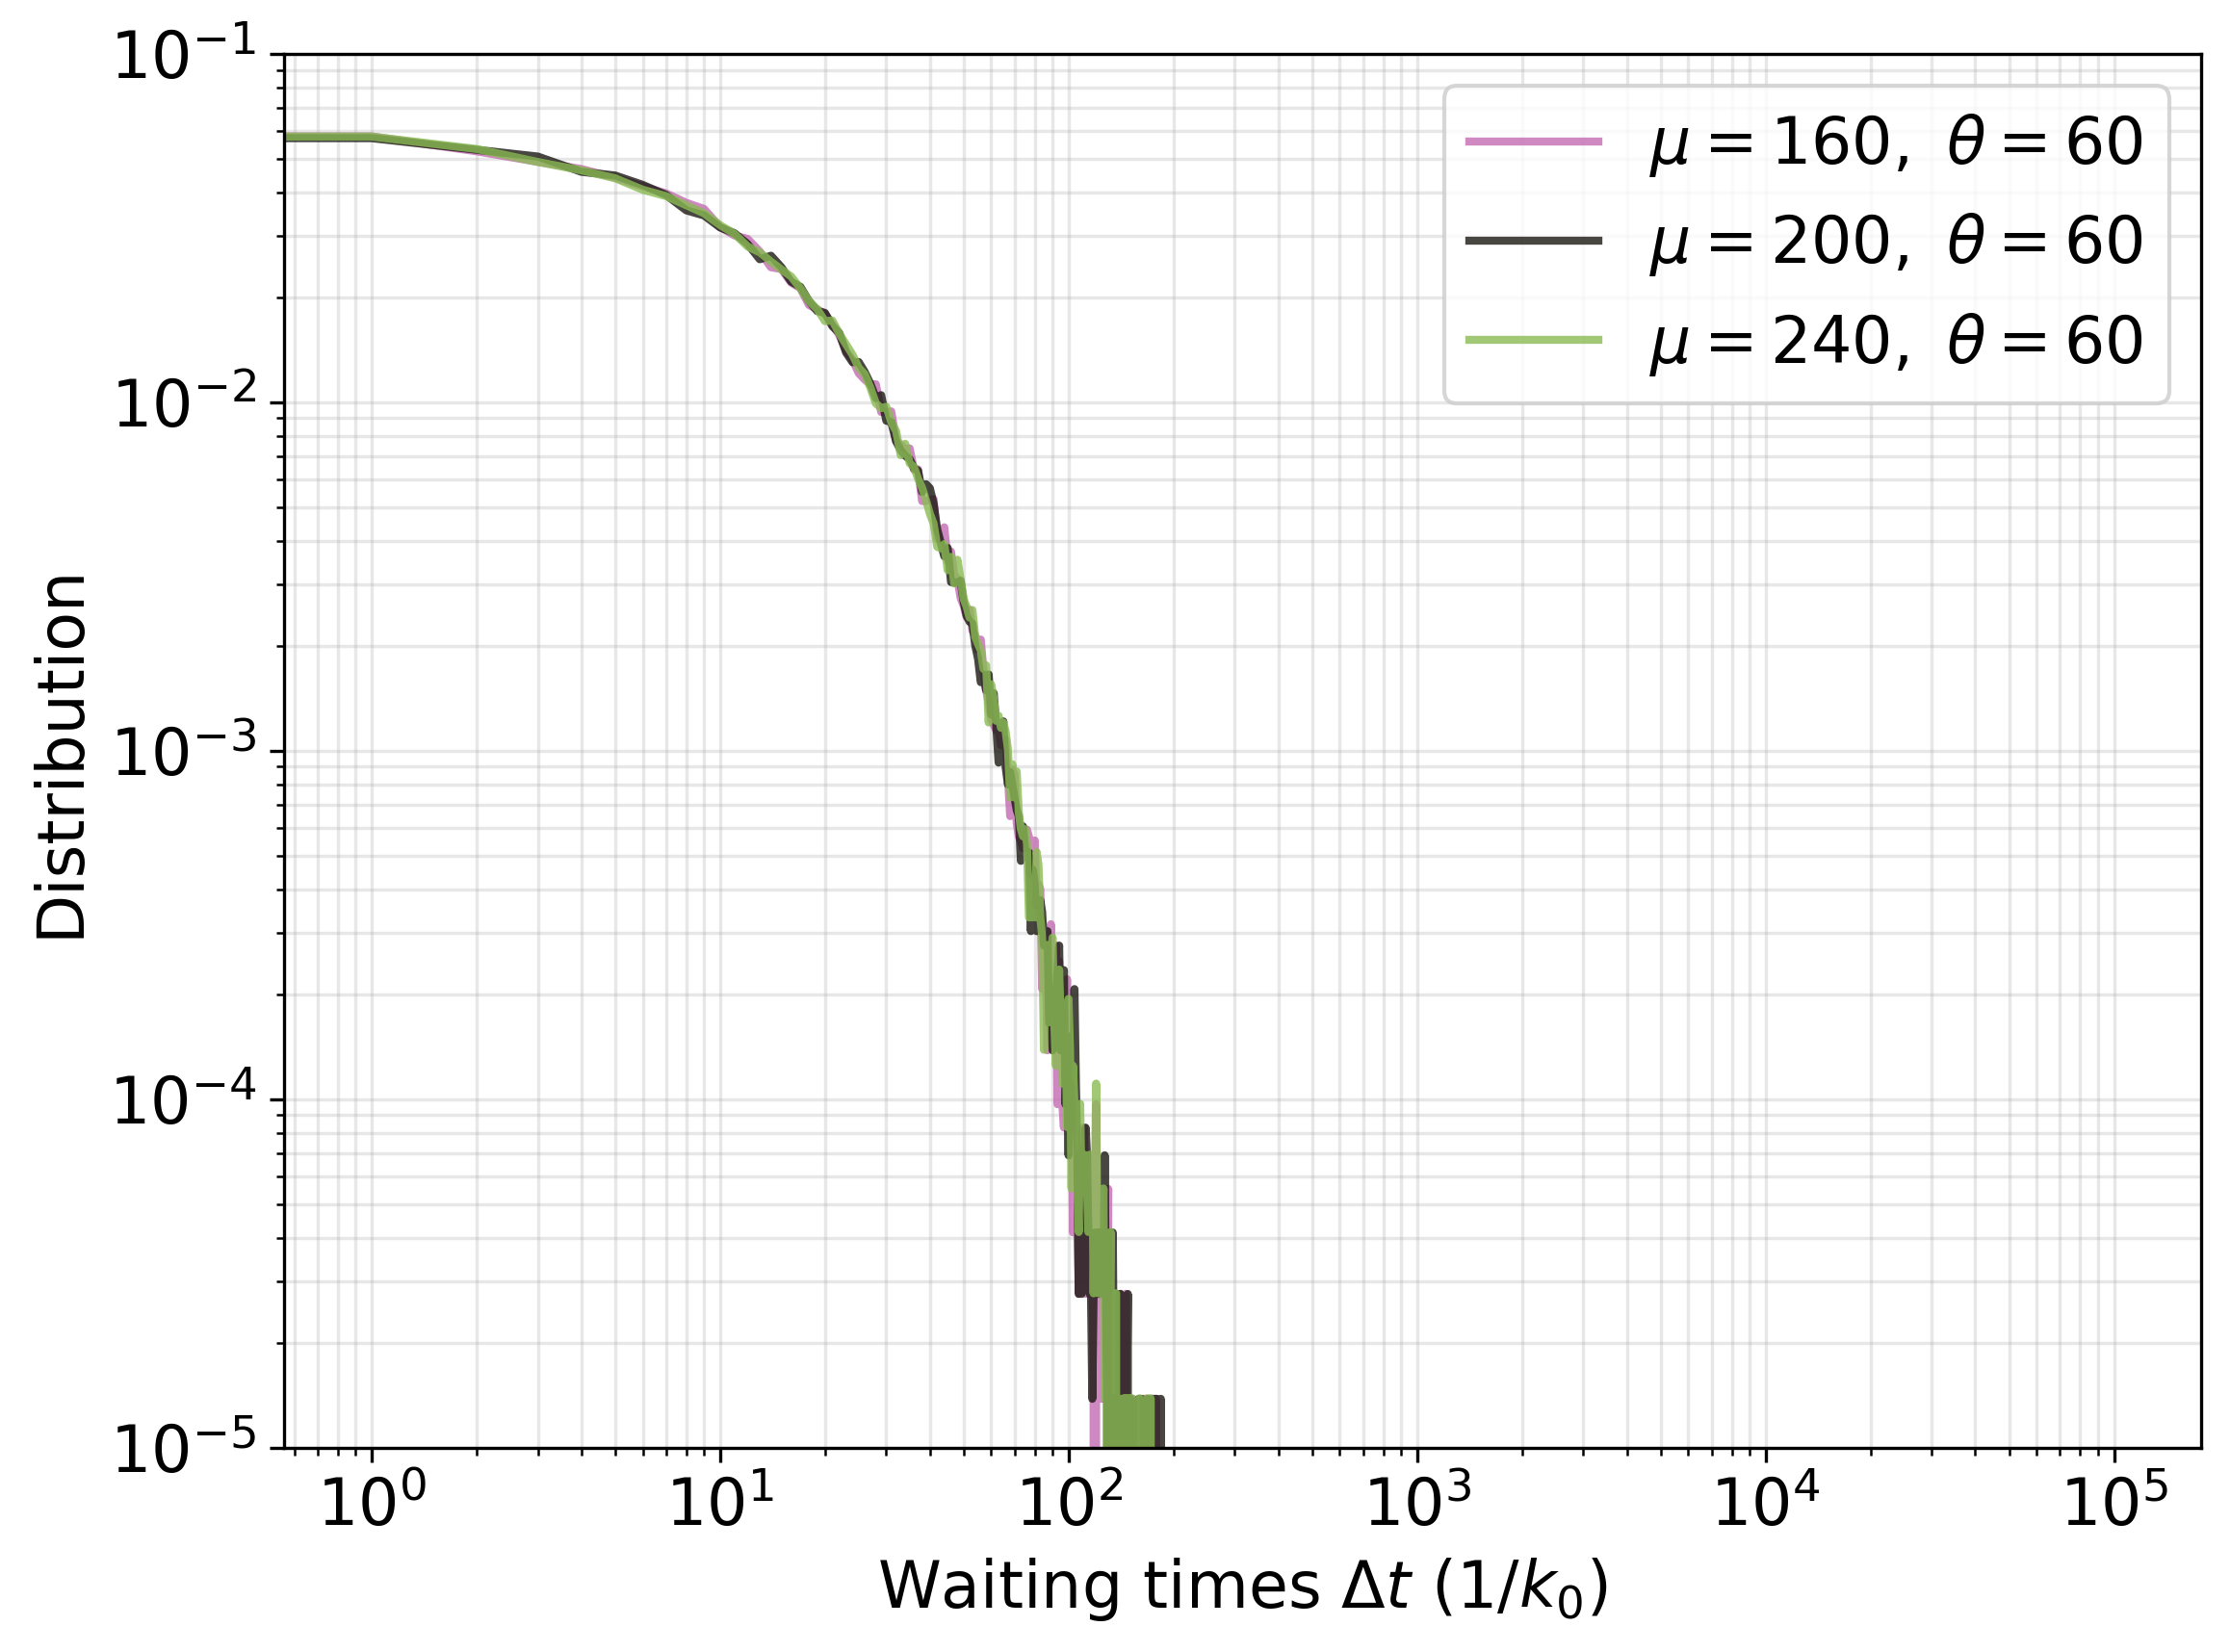

Scanning 9 parquet files...
Scanning 9 parquet files...
Scanning 9 parquet files...
periodic


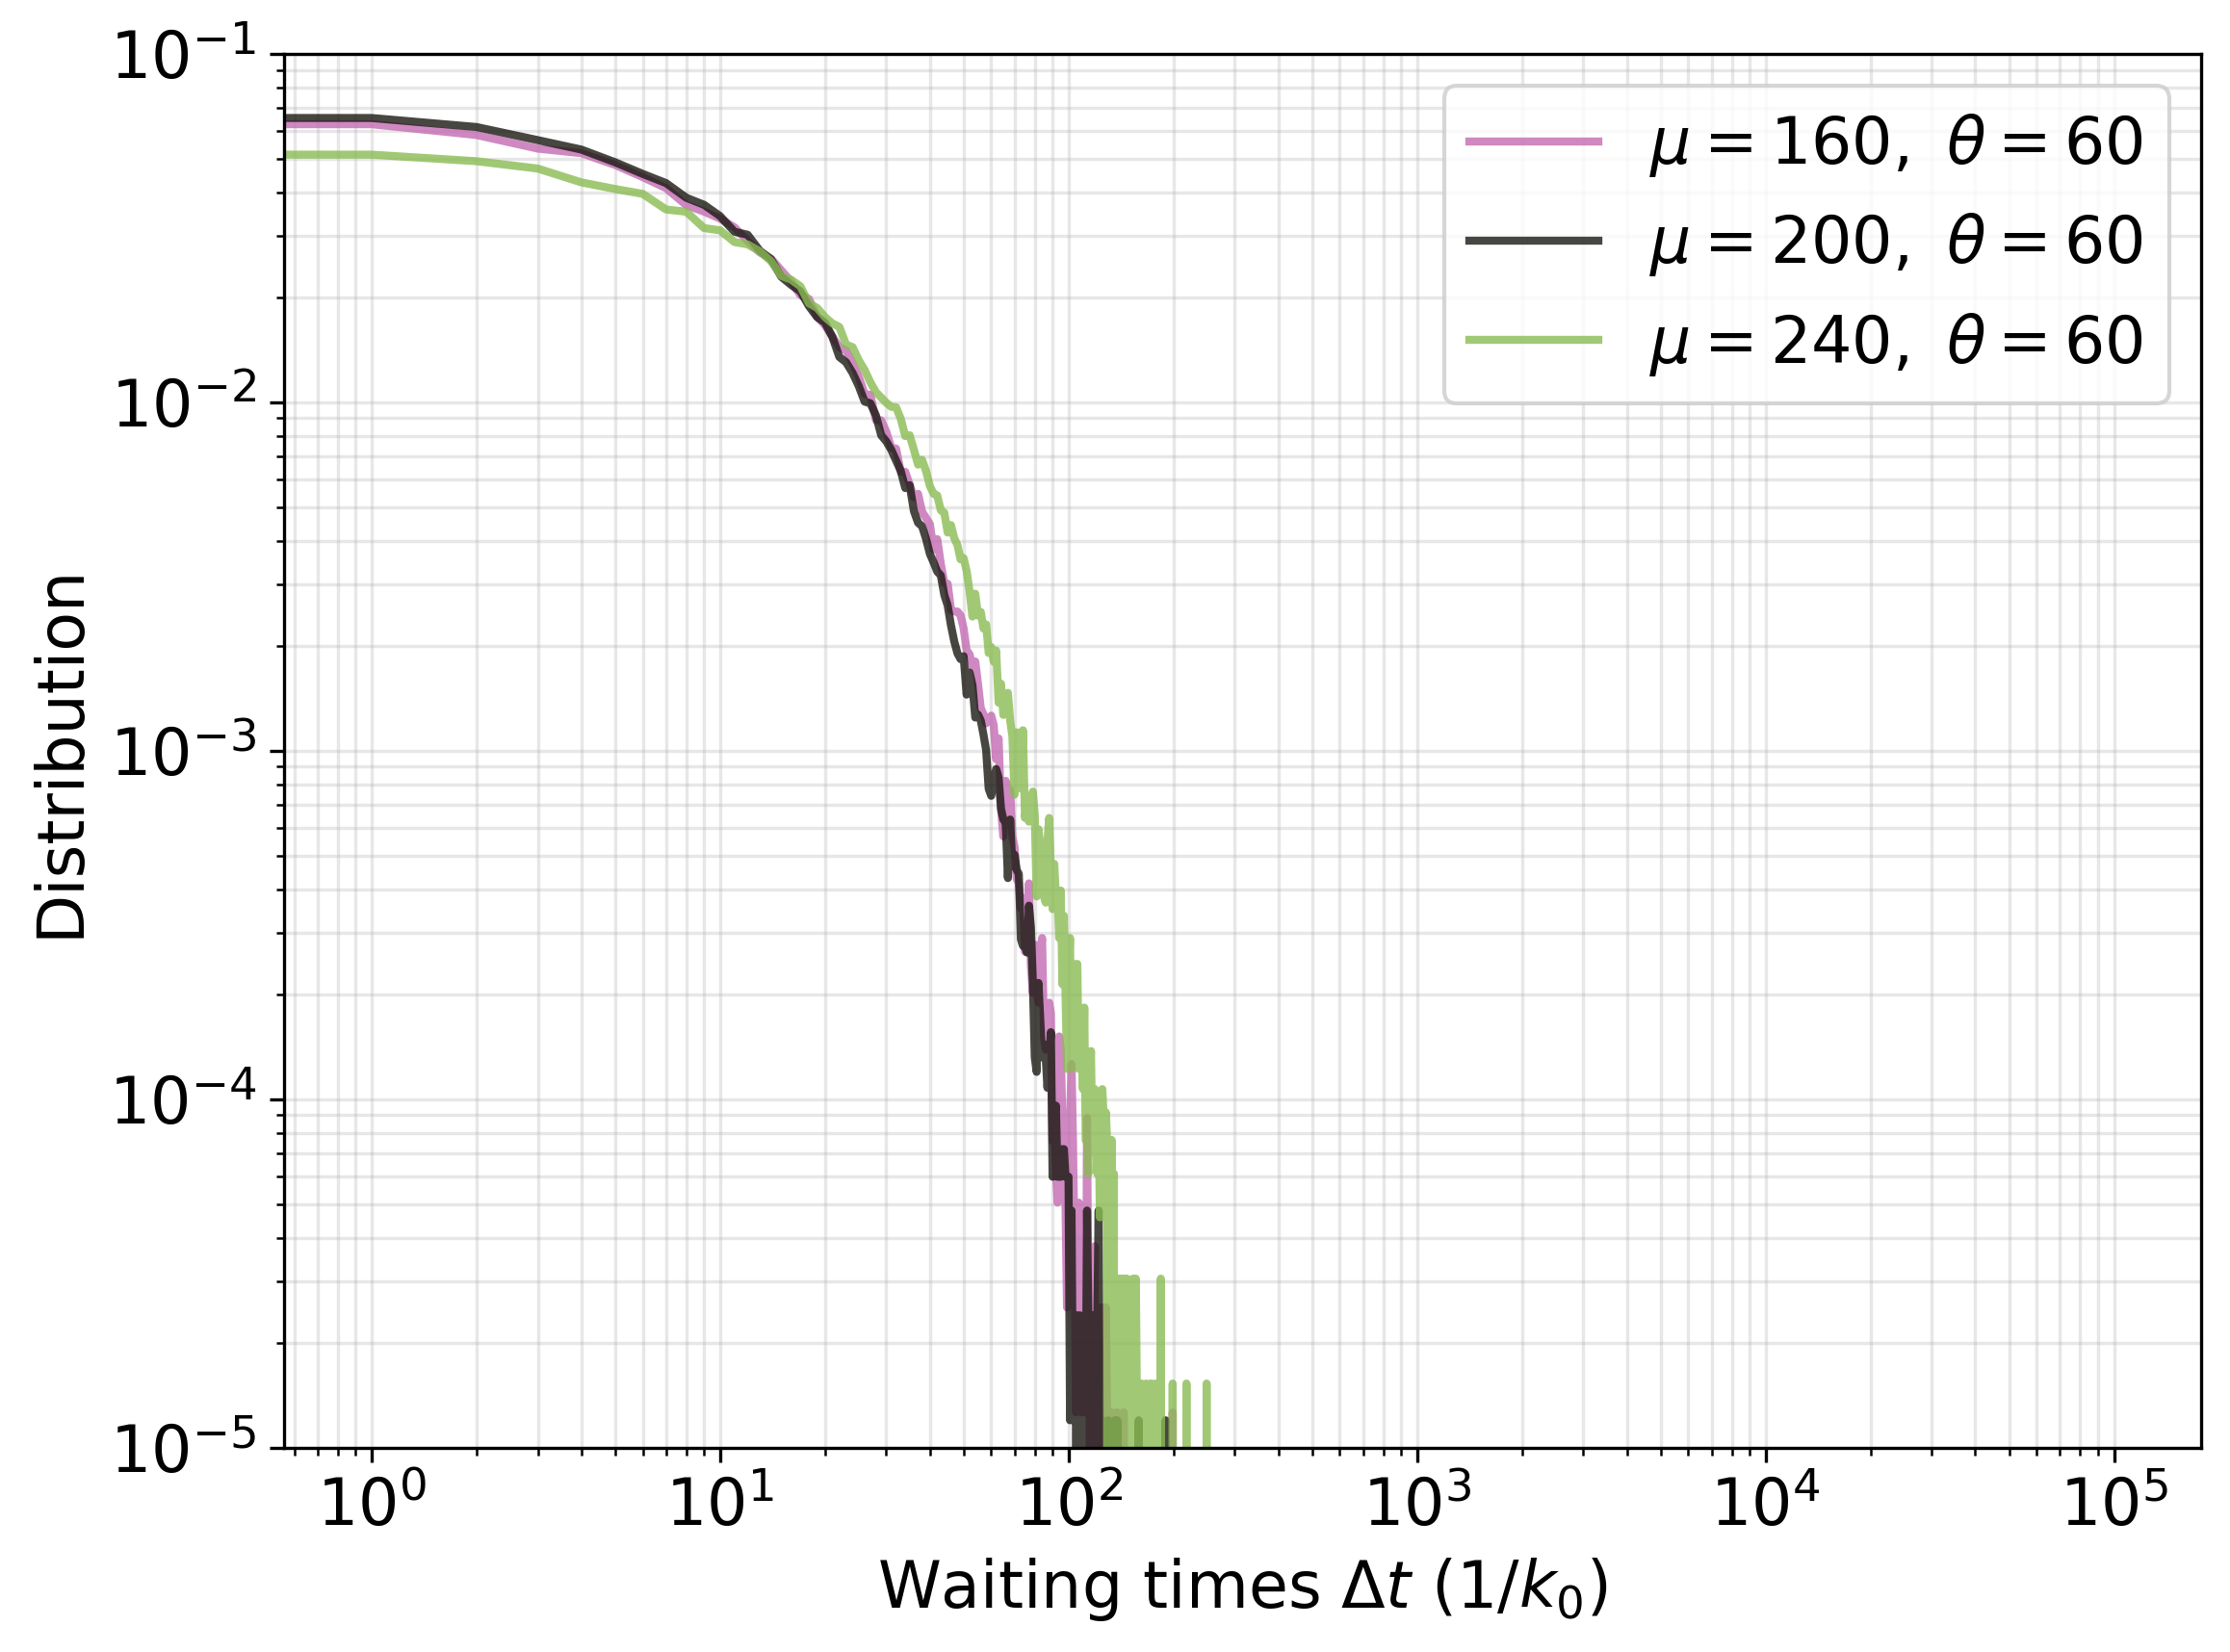

Scanning 9 parquet files...
Scanning 9 parquet files...
Scanning 9 parquet files...
random


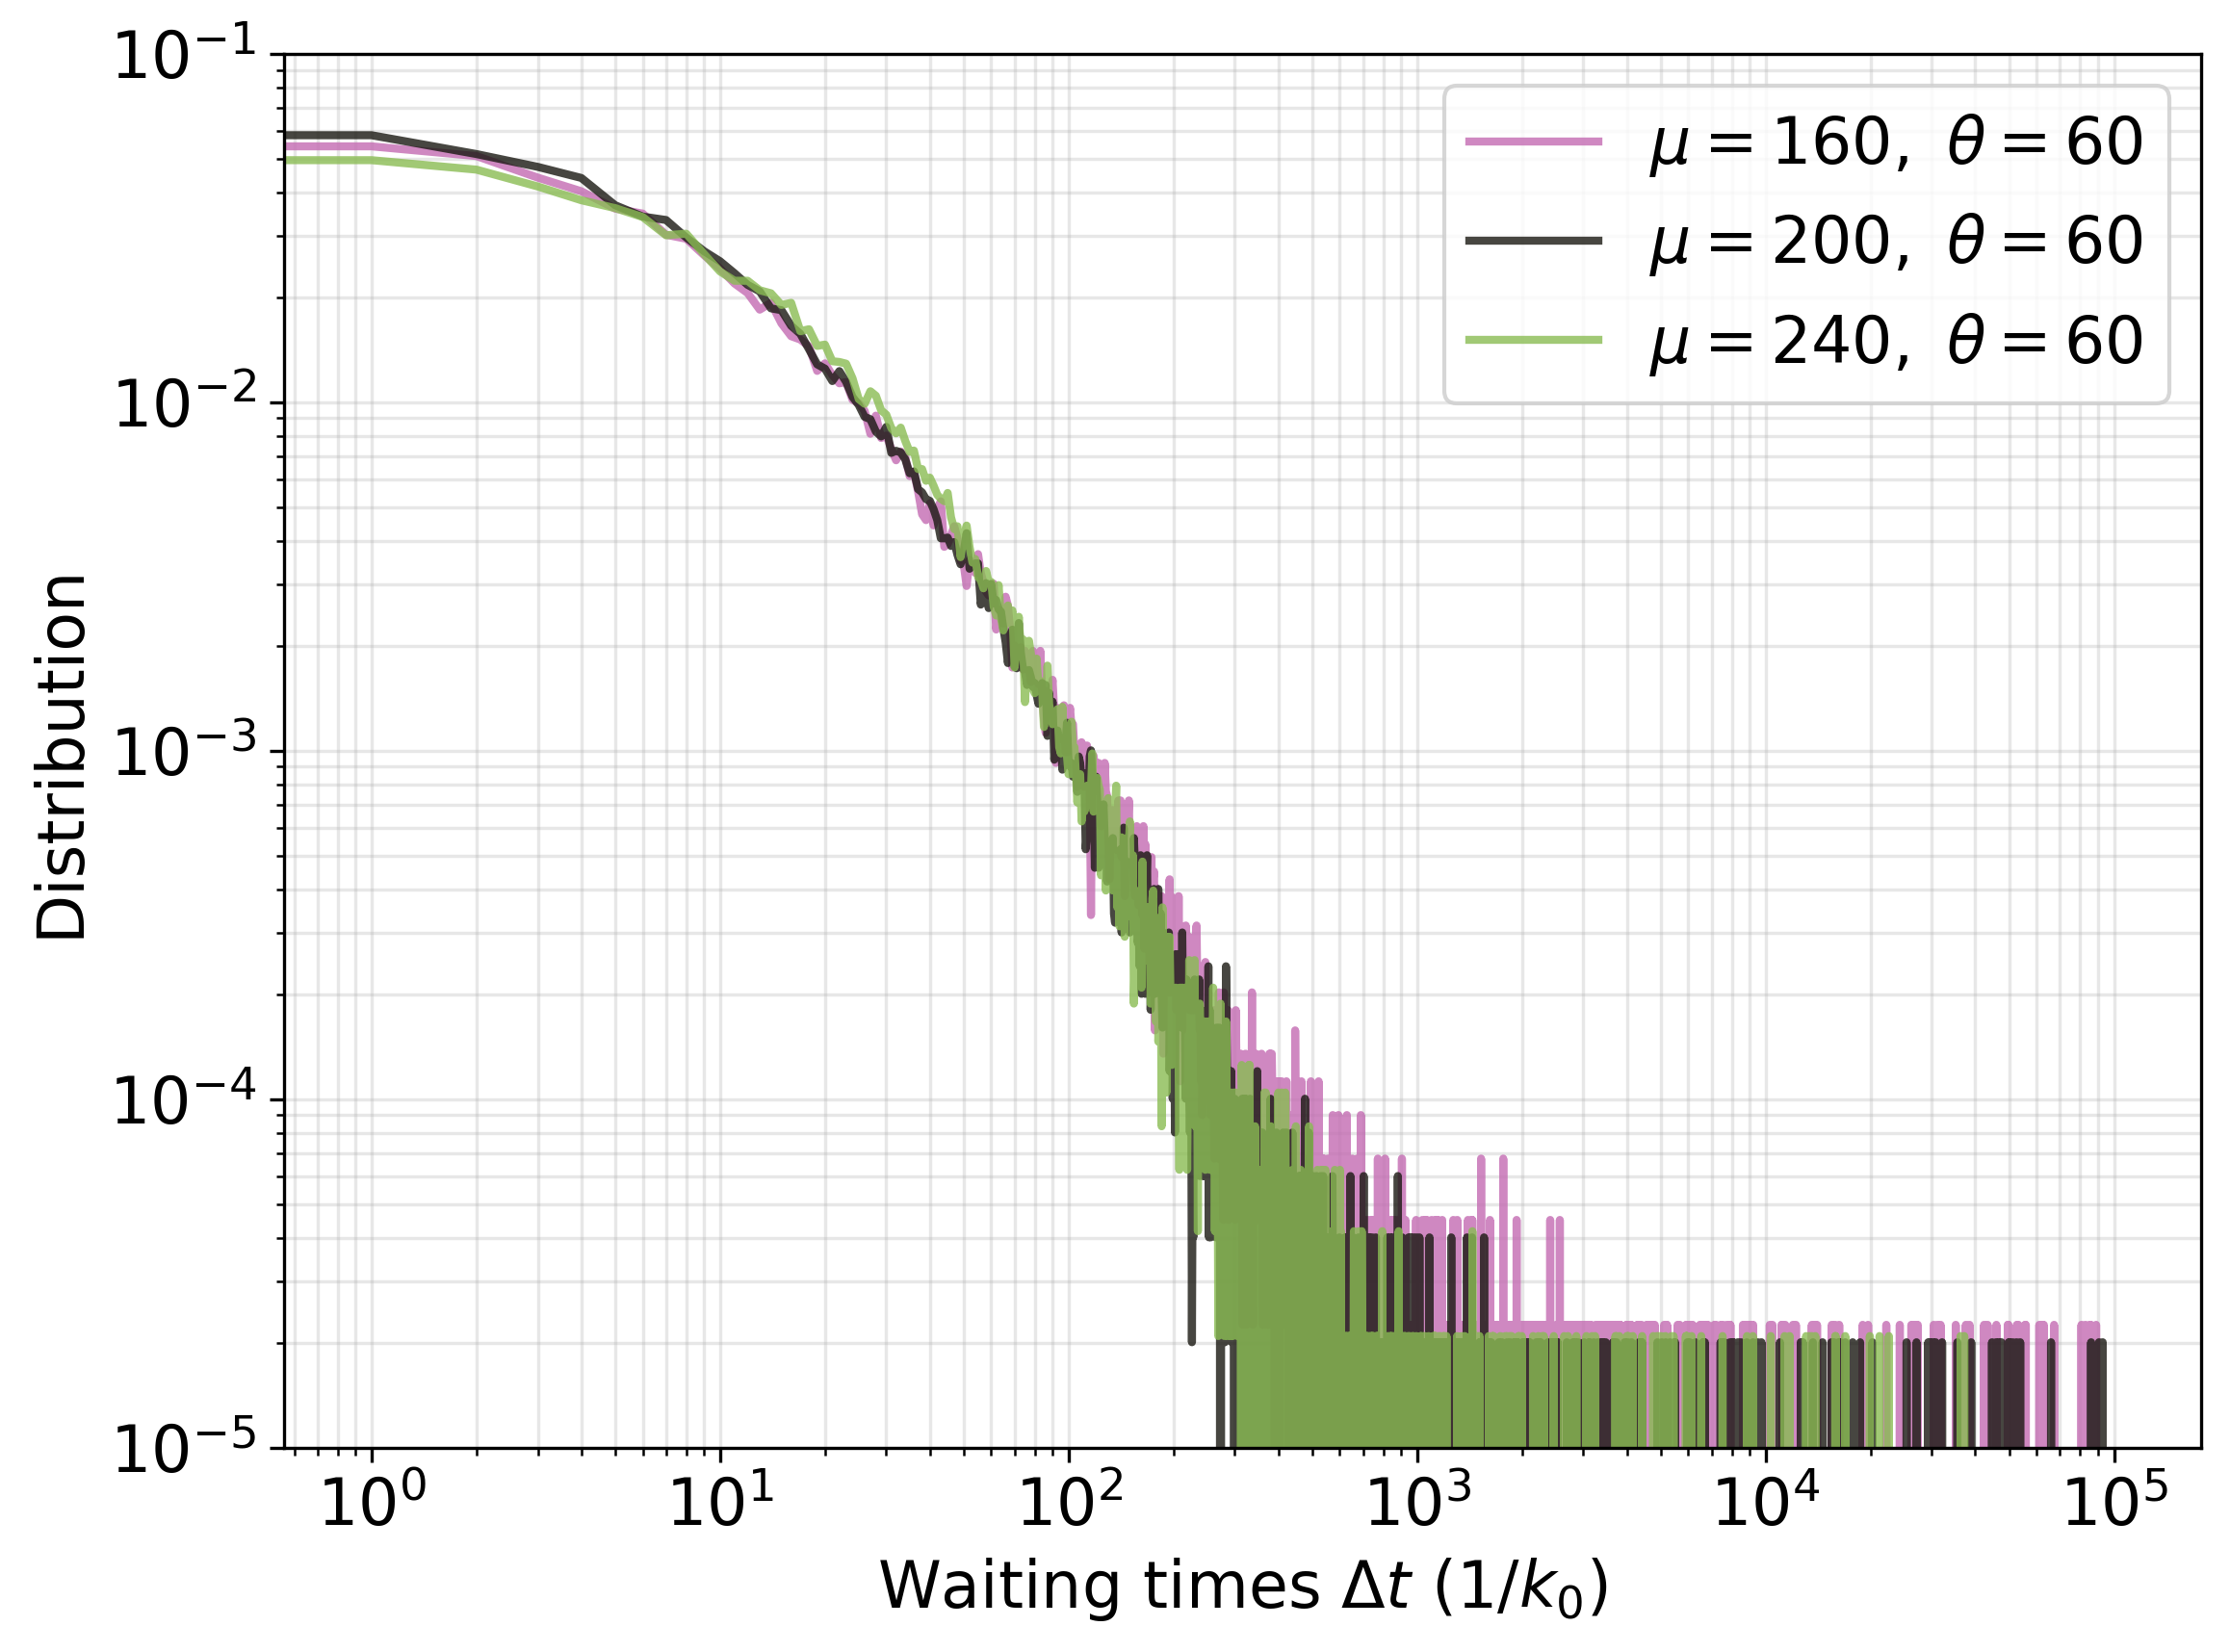

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from nucleo.io.reading import finding_one_parquet

mus = [160, 200, 240]
theta = 60

params_shared = {
    'algo'  : "1S",
    'dstr'  : False,
    'fact'  : False,
    'mode'  : "none",

    "s"     : 150,
    "l"     : 10,
    "bpmin" : 0,
    "theta" : theta,

    'Kz'    : 0.00,
    'Kp'    : 0.00,
    'alphar': 0.00,
}

cmap = cm.get_cmap("vanimo")
colors = cmap(np.linspace(0.15, 0.90, len(mus)))

for land in ["homogen", "periodic", "random"]:

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    params = params_shared.copy()
    params["land"] = land

    for mu, c in zip(mus, colors):

        params["mu"] = mu

        df = finding_one_parquet(root, params)

        ax.plot(
            df["tbj_points"][0].to_numpy(),
            df["tbj_distrib"][0].to_numpy(),
            color=c,
            alpha=0.8,
            lw=2,
            label=fr"$\mu={mu},\ \theta={theta}$"
        )

    # ax.set_title(land.capitalize())
    print(land)
    ax.set_xlabel(r"Waiting times $\Delta t\ (1/k_0)$")
    ax.set_ylabel("Distribution")

    ax.set_ylim([1e-5, 1e-1])

    ax.loglog()
    ax.grid(True, which="both", alpha=0.30)
    ax.legend()

    fig.tight_layout()

    plt.savefig(
        f"supfig3_{land}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

/tmp/ipykernel_25190/1858830425.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("vanimo")


Scanning 9 parquet files...
Scanning 9 parquet files...
Scanning 9 parquet files...
homogen


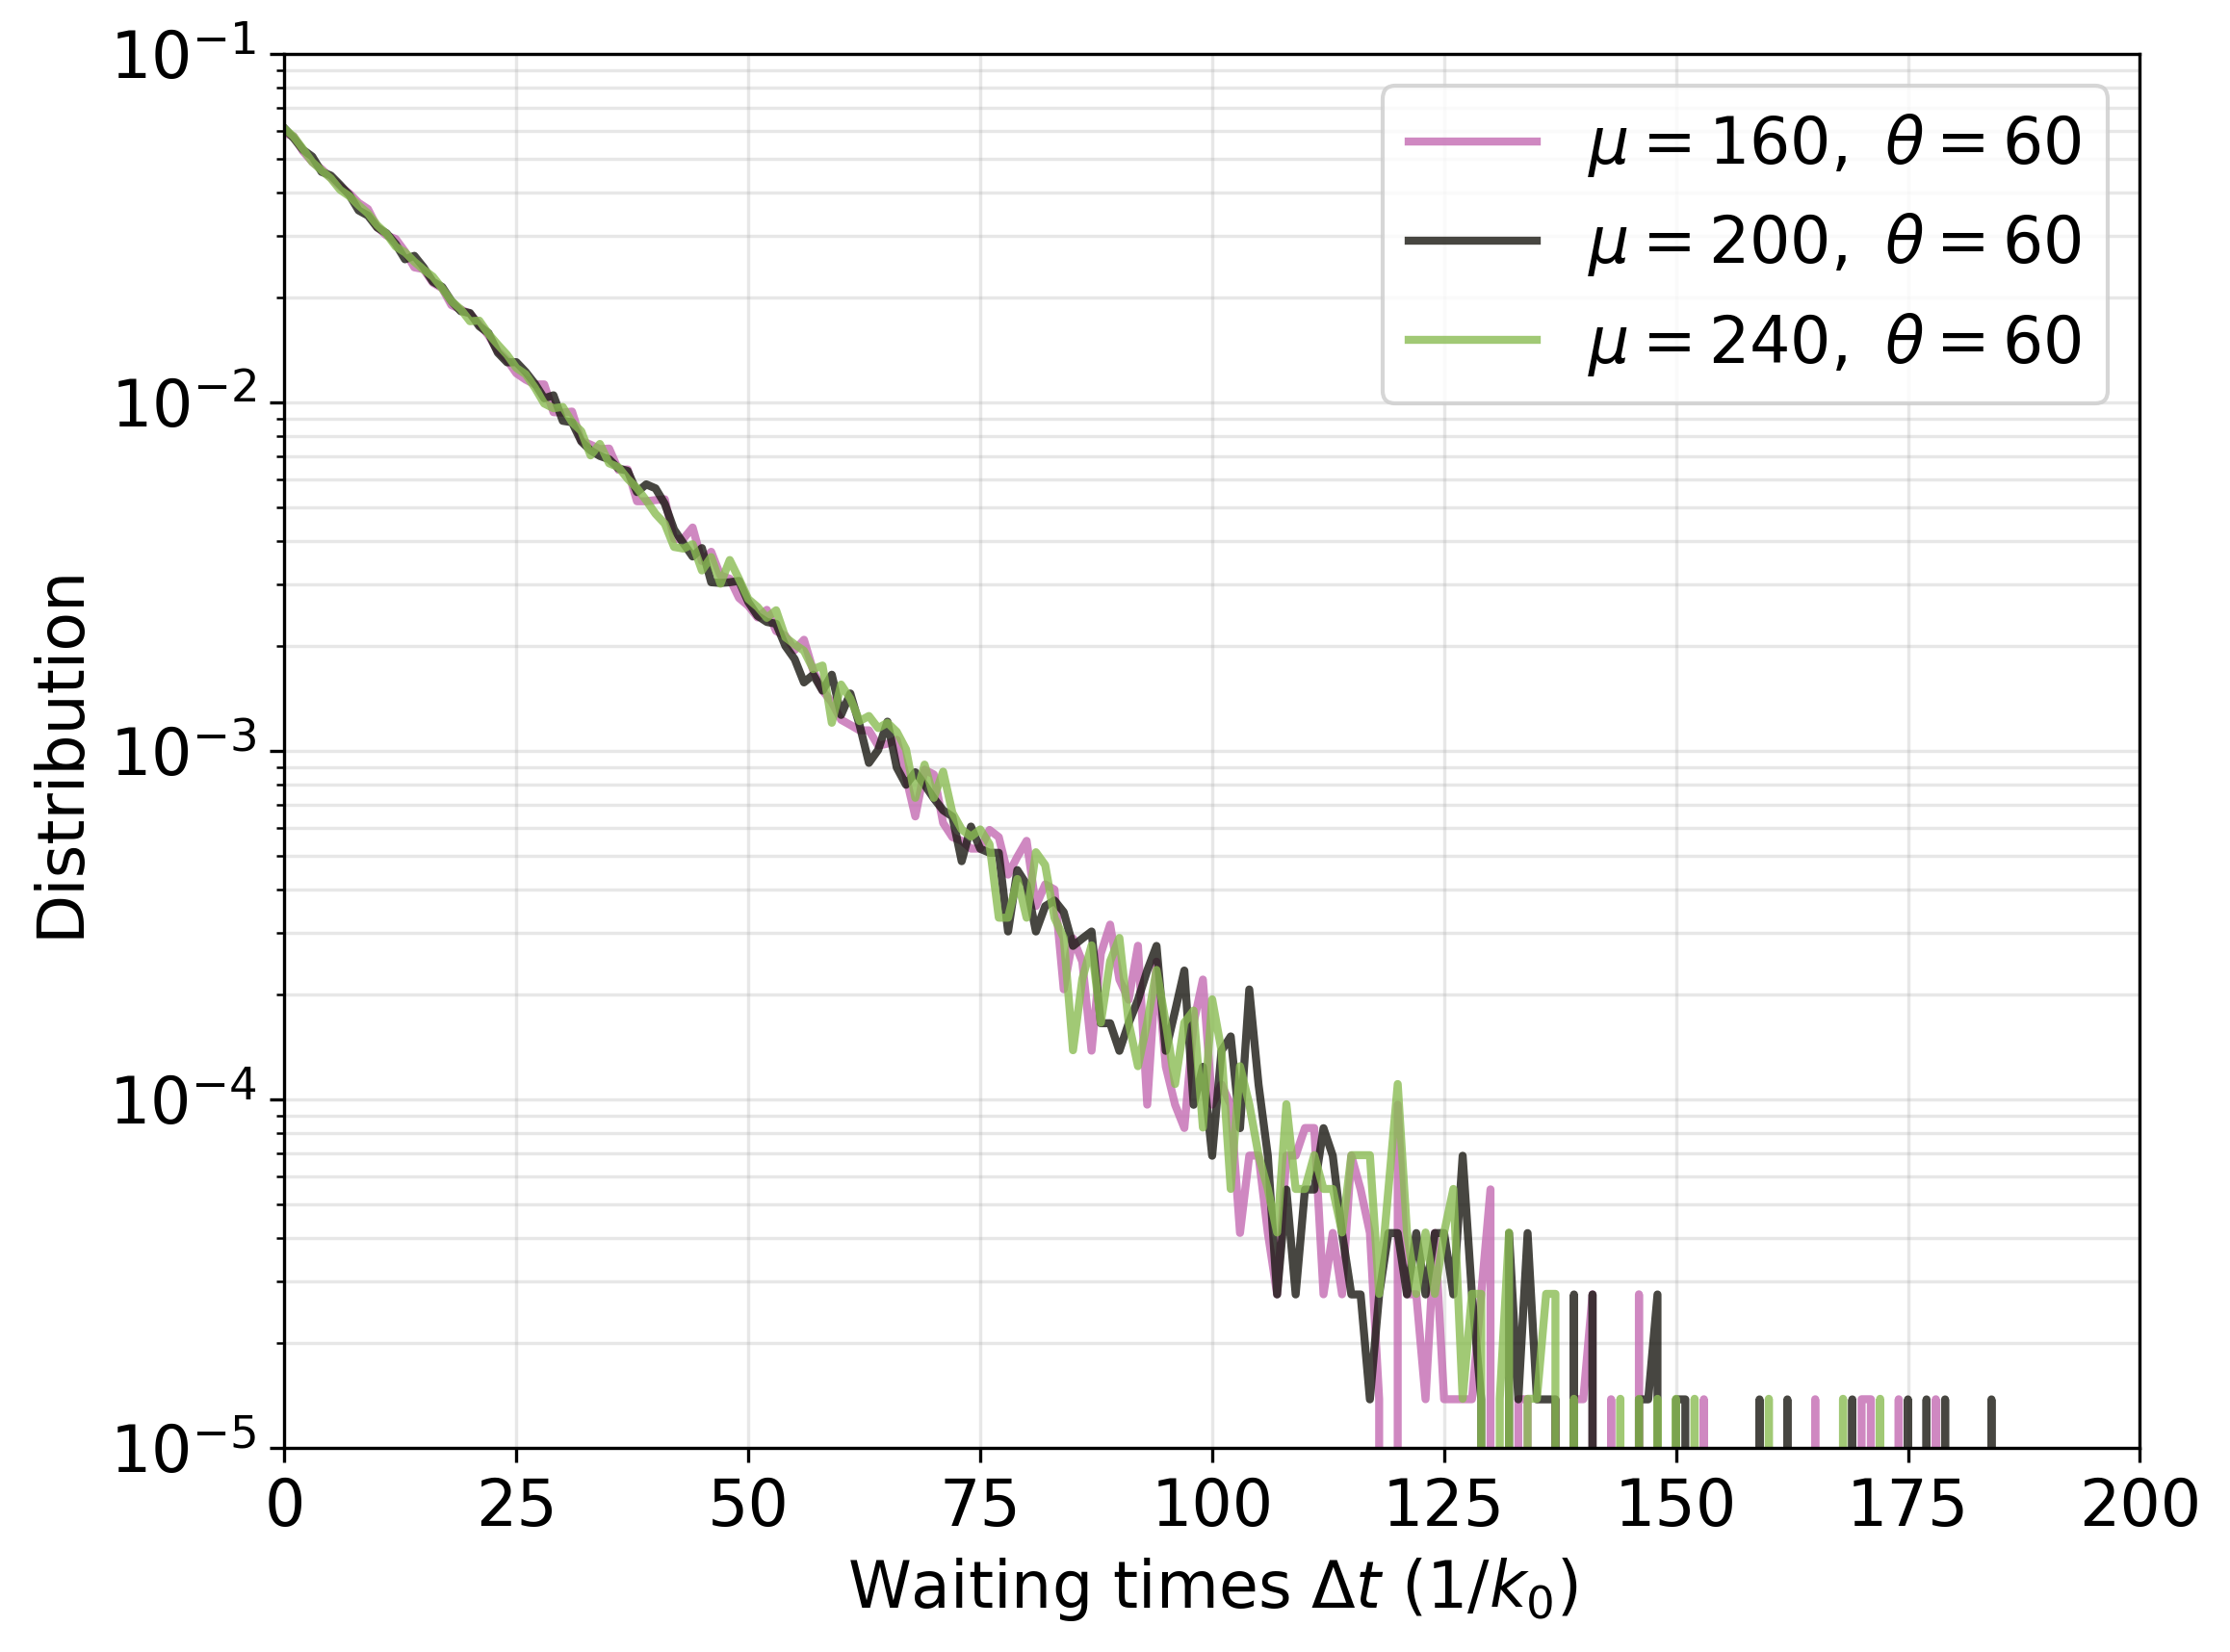

Scanning 9 parquet files...
Scanning 9 parquet files...
Scanning 9 parquet files...
periodic


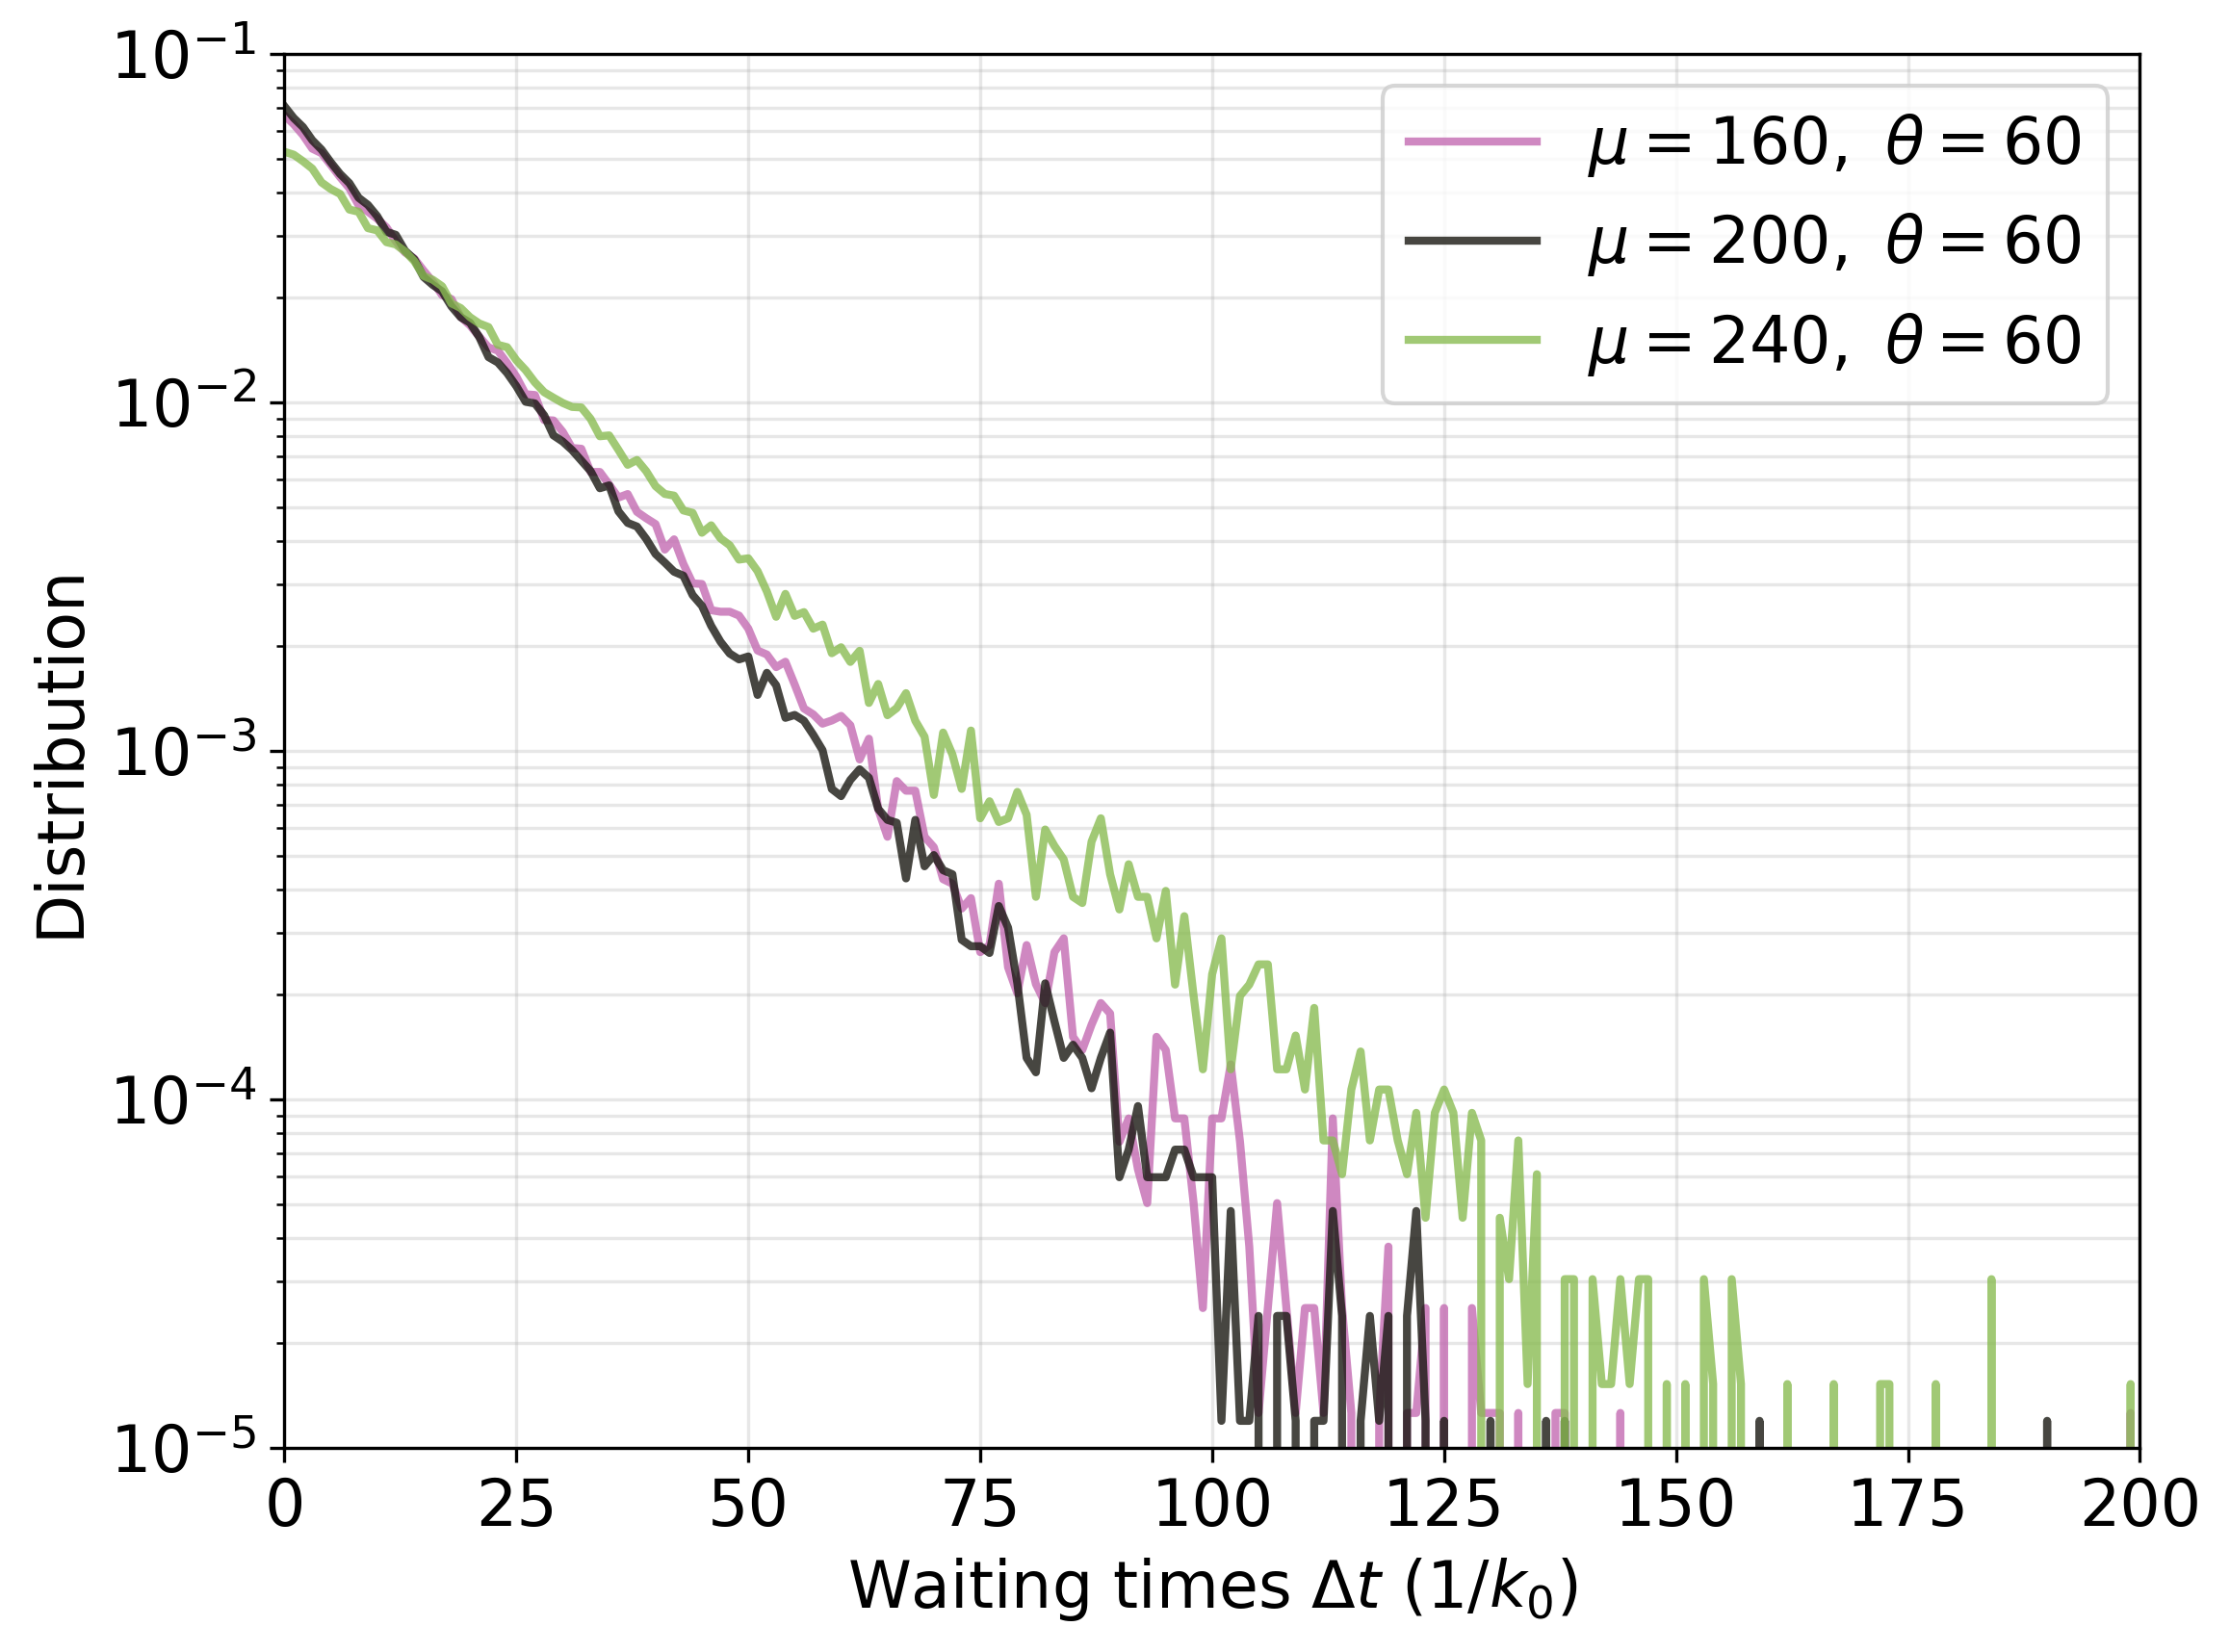

Scanning 9 parquet files...
Scanning 9 parquet files...
Scanning 9 parquet files...
random


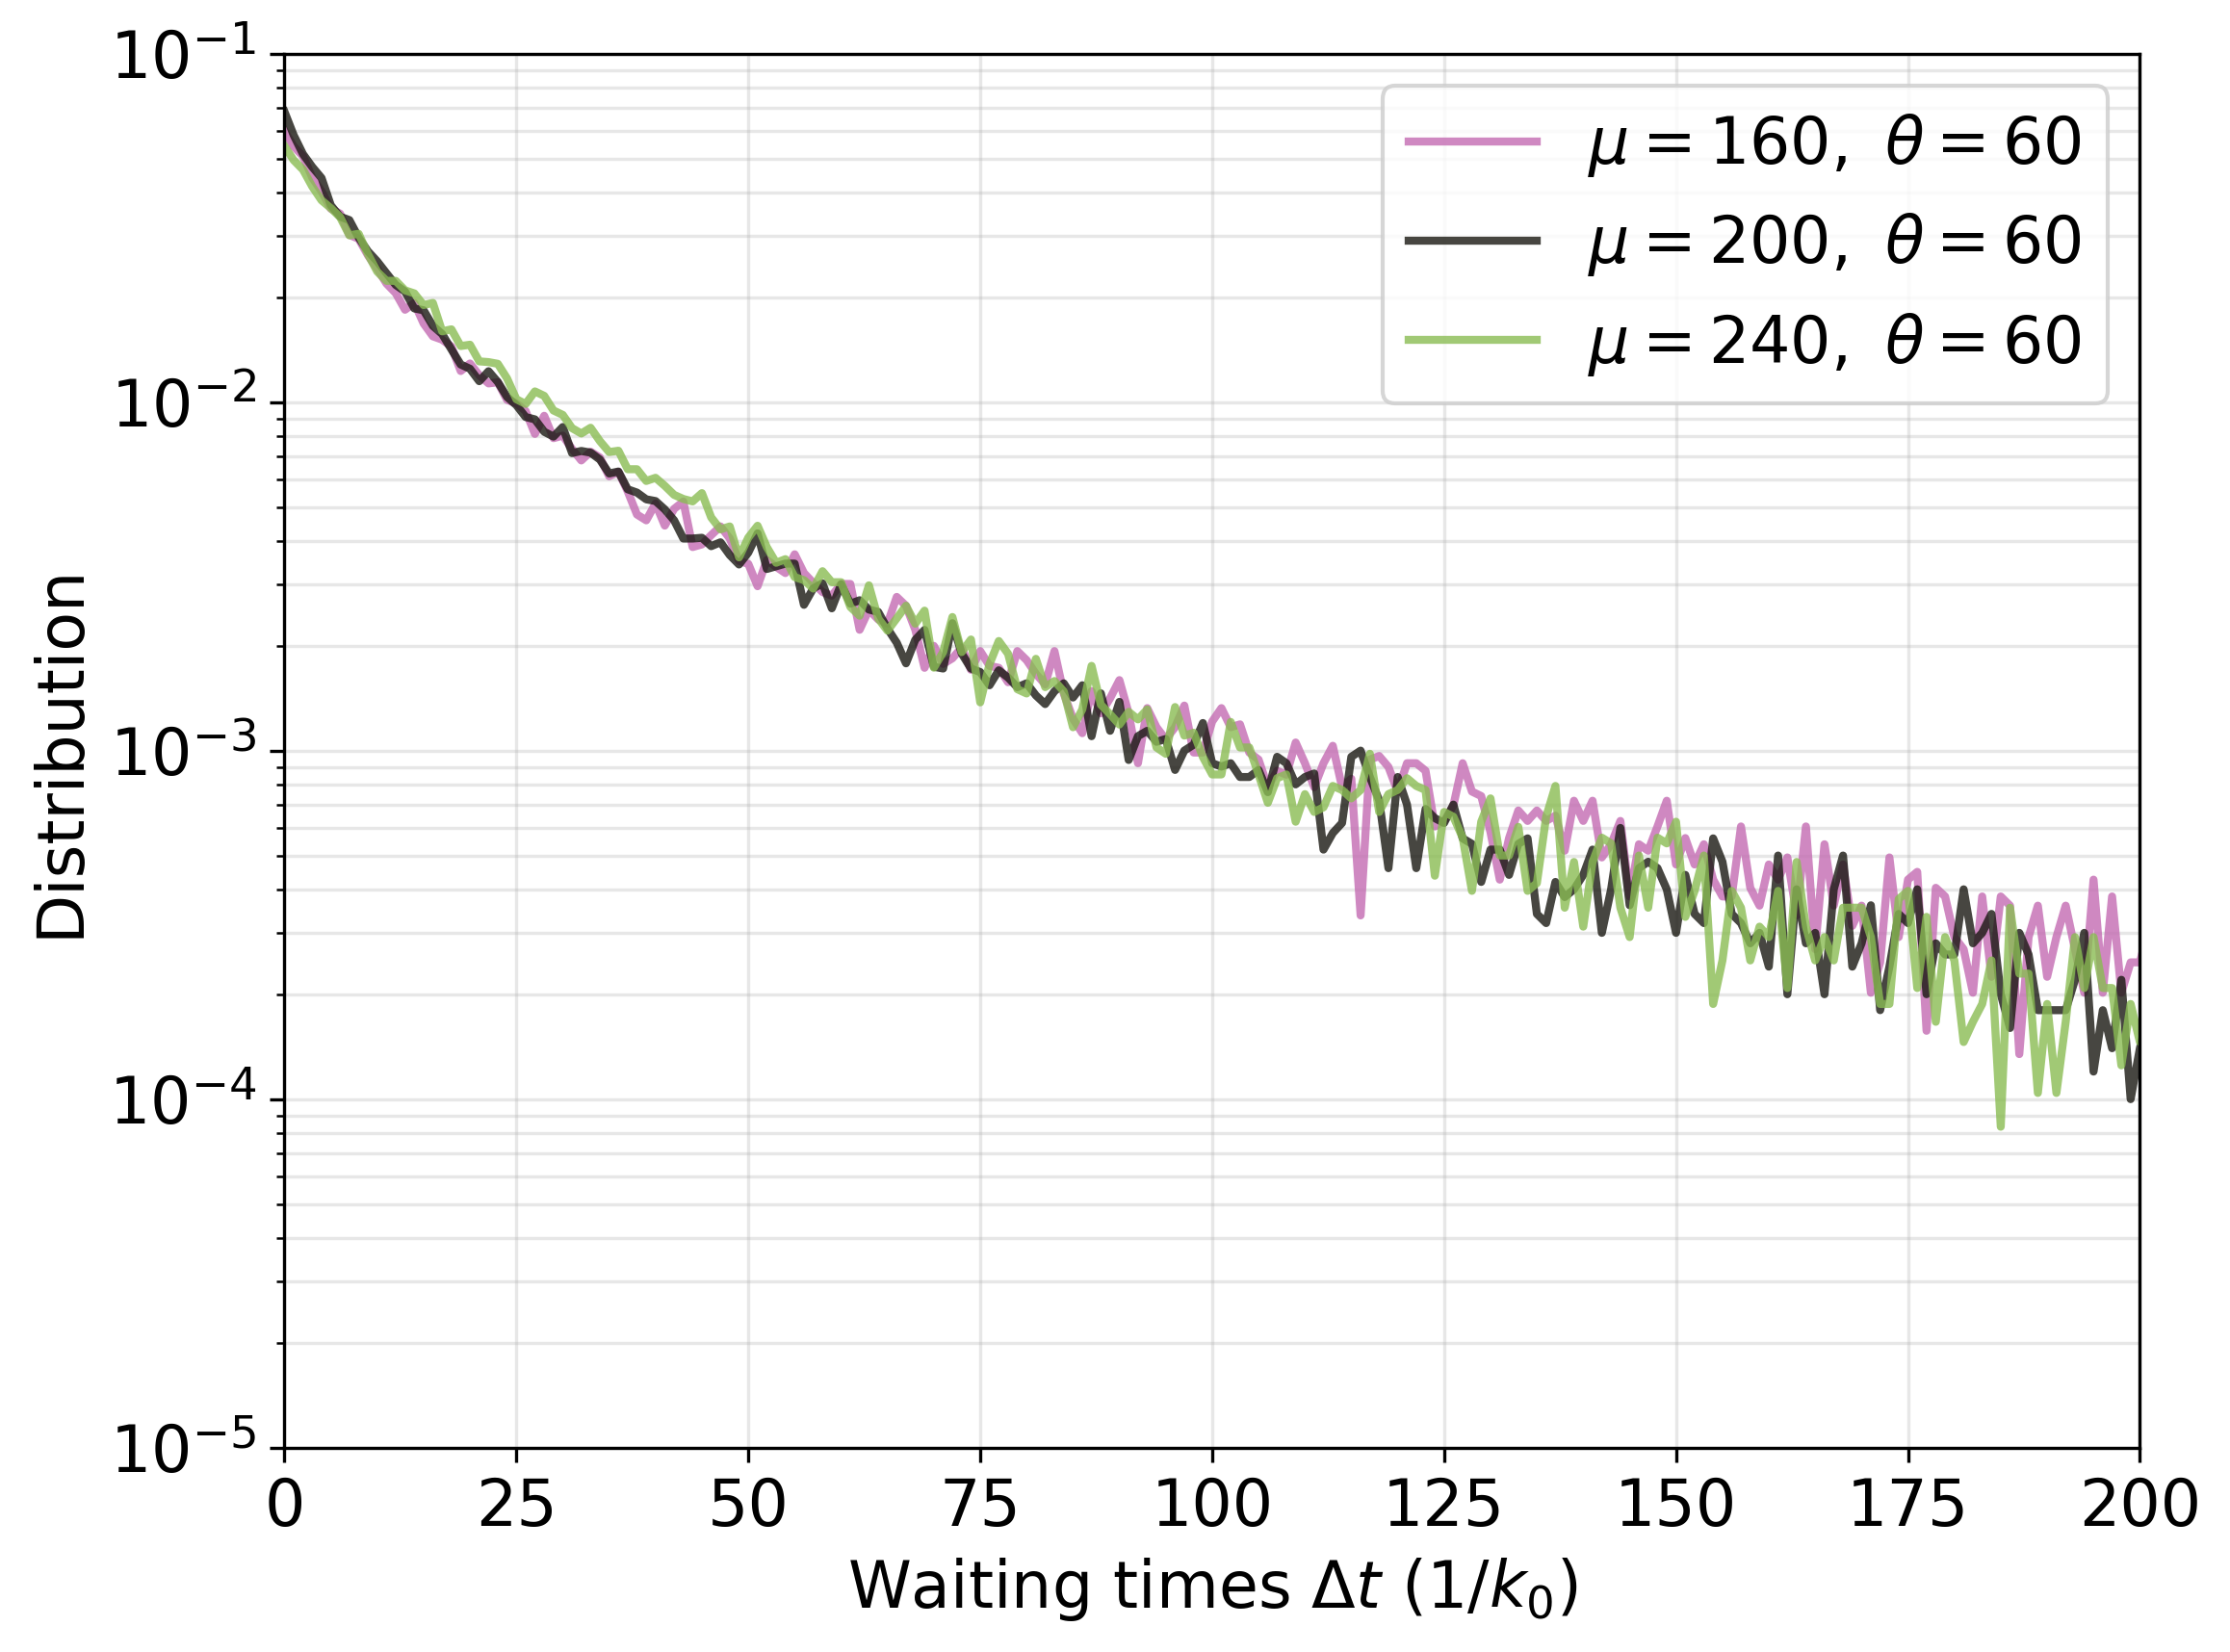

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from nucleo.io.reading import finding_one_parquet

mus = [160, 200, 240]
theta = 60

params_shared = {
    'algo'  : "1S",
    'dstr'  : False,
    'fact'  : False,
    'mode'  : "none",

    "s"     : 150,
    "l"     : 10,
    "bpmin" : 0,
    "theta" : theta,

    'Kz'    : 0.00,
    'Kp'    : 0.00,
    'alphar': 0.00,
}

cmap = cm.get_cmap("vanimo")
colors = cmap(np.linspace(0.15, 0.90, len(mus)))

for land in ["homogen", "periodic", "random"]:

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    params = params_shared.copy()
    params["land"] = land

    for mu, c in zip(mus, colors):

        params["mu"] = mu

        df = finding_one_parquet(root, params)

        ax.plot(
            df["tbj_points"][0].to_numpy(),
            df["tbj_distrib"][0].to_numpy(),
            color=c,
            alpha=0.8,
            lw=2,
            label=fr"$\mu={mu},\ \theta={theta}$"
        )

    # ax.set_title(land.capitalize())
    print(land)
    ax.set_xlabel(r"Waiting times $\Delta t\ (1/k_0)$")
    ax.set_ylabel("Distribution")

    # Log-lin : x logarithmique, y linéaire
    ax.set_yscale("log")
    ax.set_xlim([0, 200])
    ax.set_ylim([1e-5, 1e-1])

    ax.grid(True, which="both", alpha=0.30)
    ax.legend()

    fig.tight_layout()

    plt.savefig(
        f"supfig3_{land}_loglin.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

/tmp/ipykernel_25190/2184740488.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("vanimo")


Scanning 9 parquet files...
Scanning 9 parquet files...
Scanning 9 parquet files...
homogen


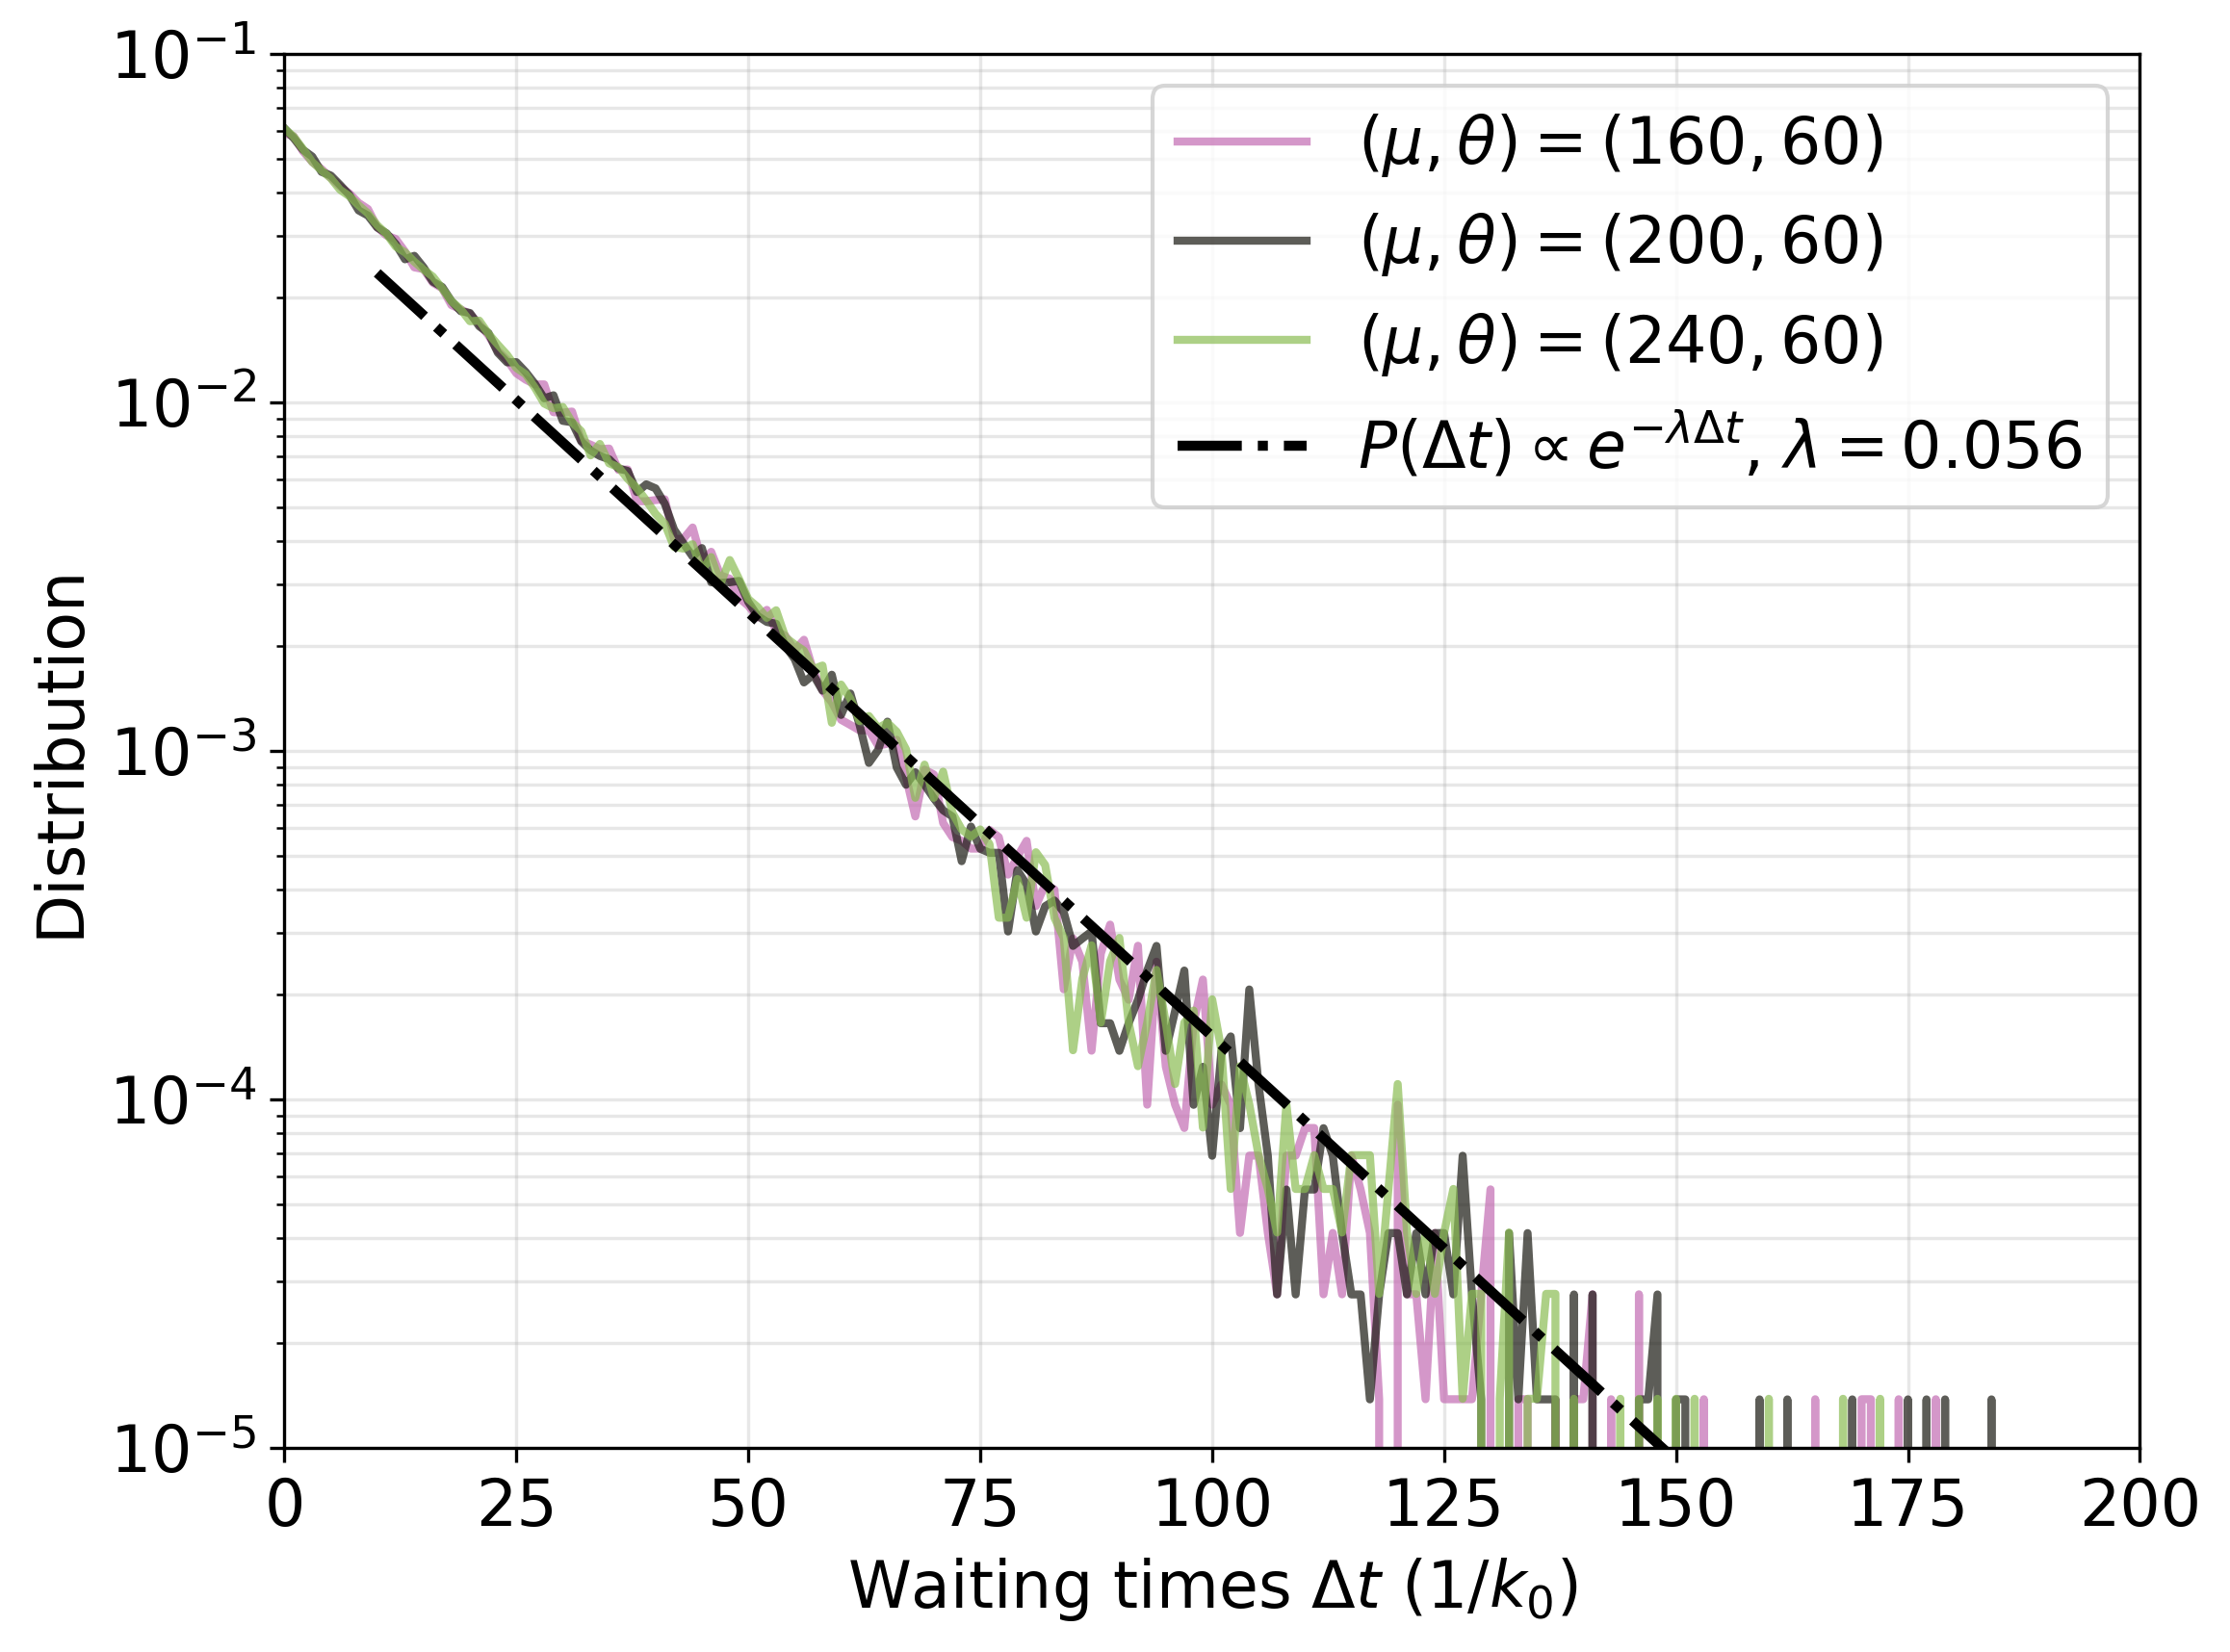

Scanning 9 parquet files...
Scanning 9 parquet files...
Scanning 9 parquet files...
periodic


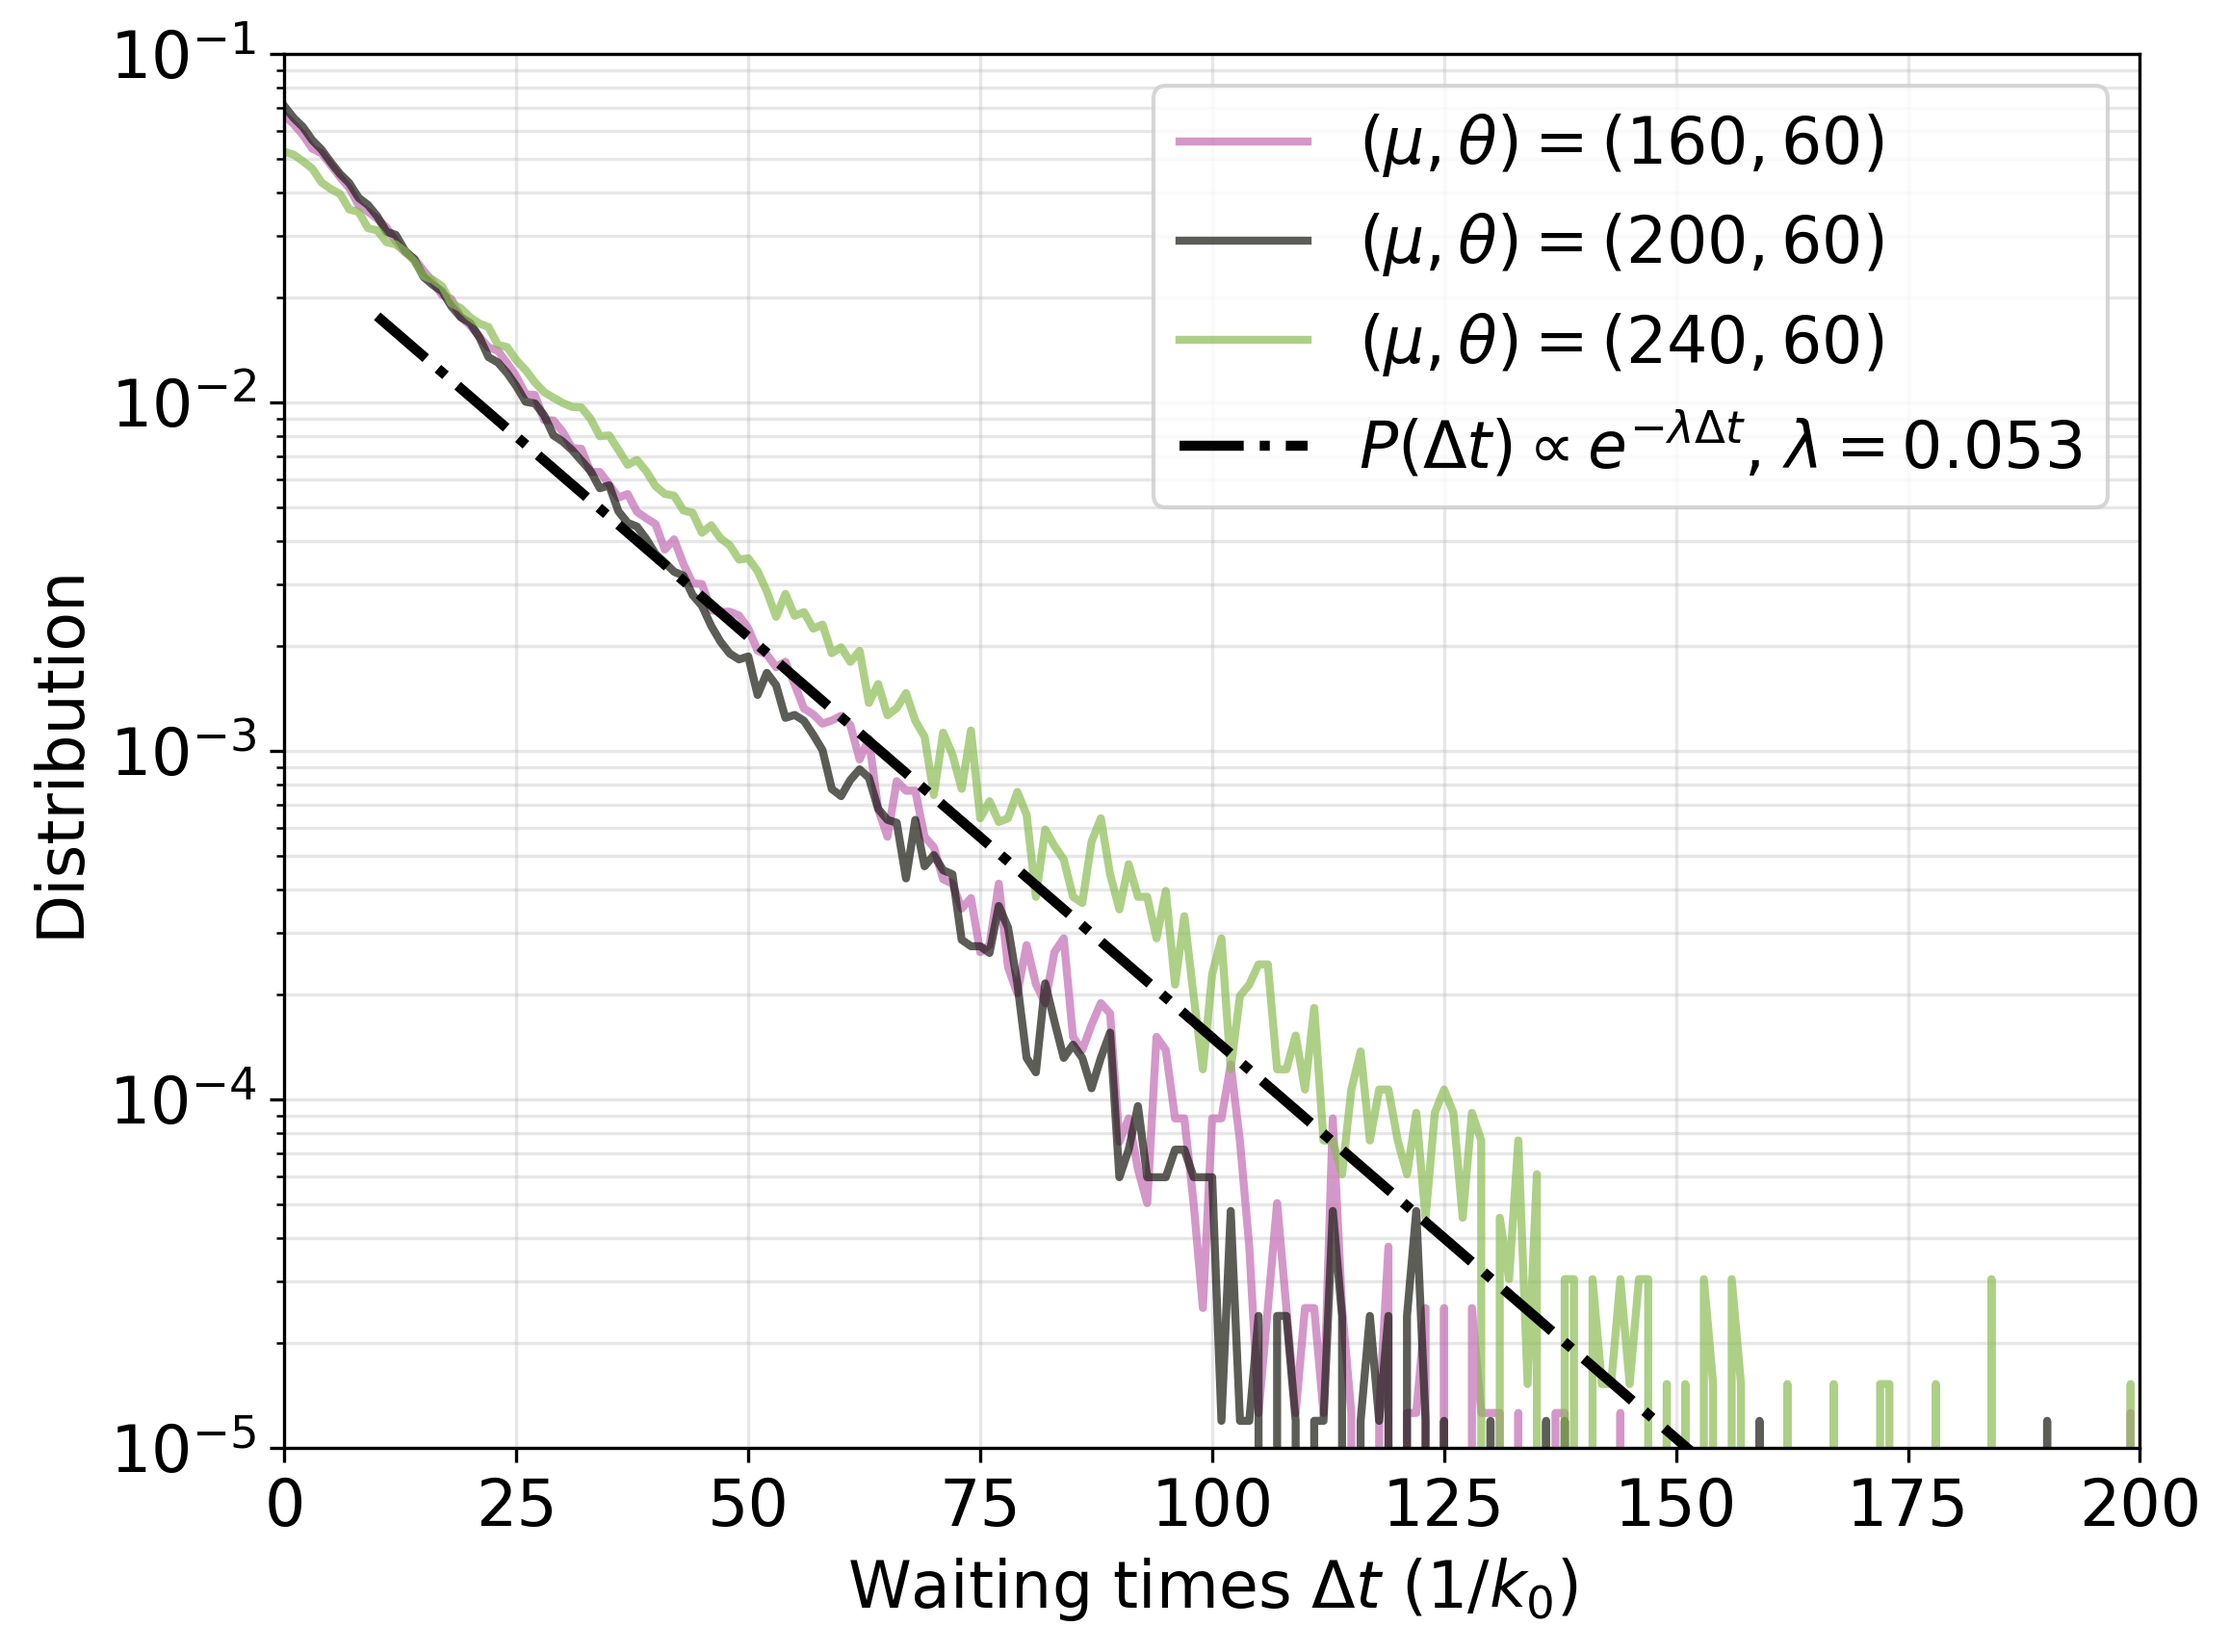

Scanning 9 parquet files...
Scanning 9 parquet files...
Scanning 9 parquet files...


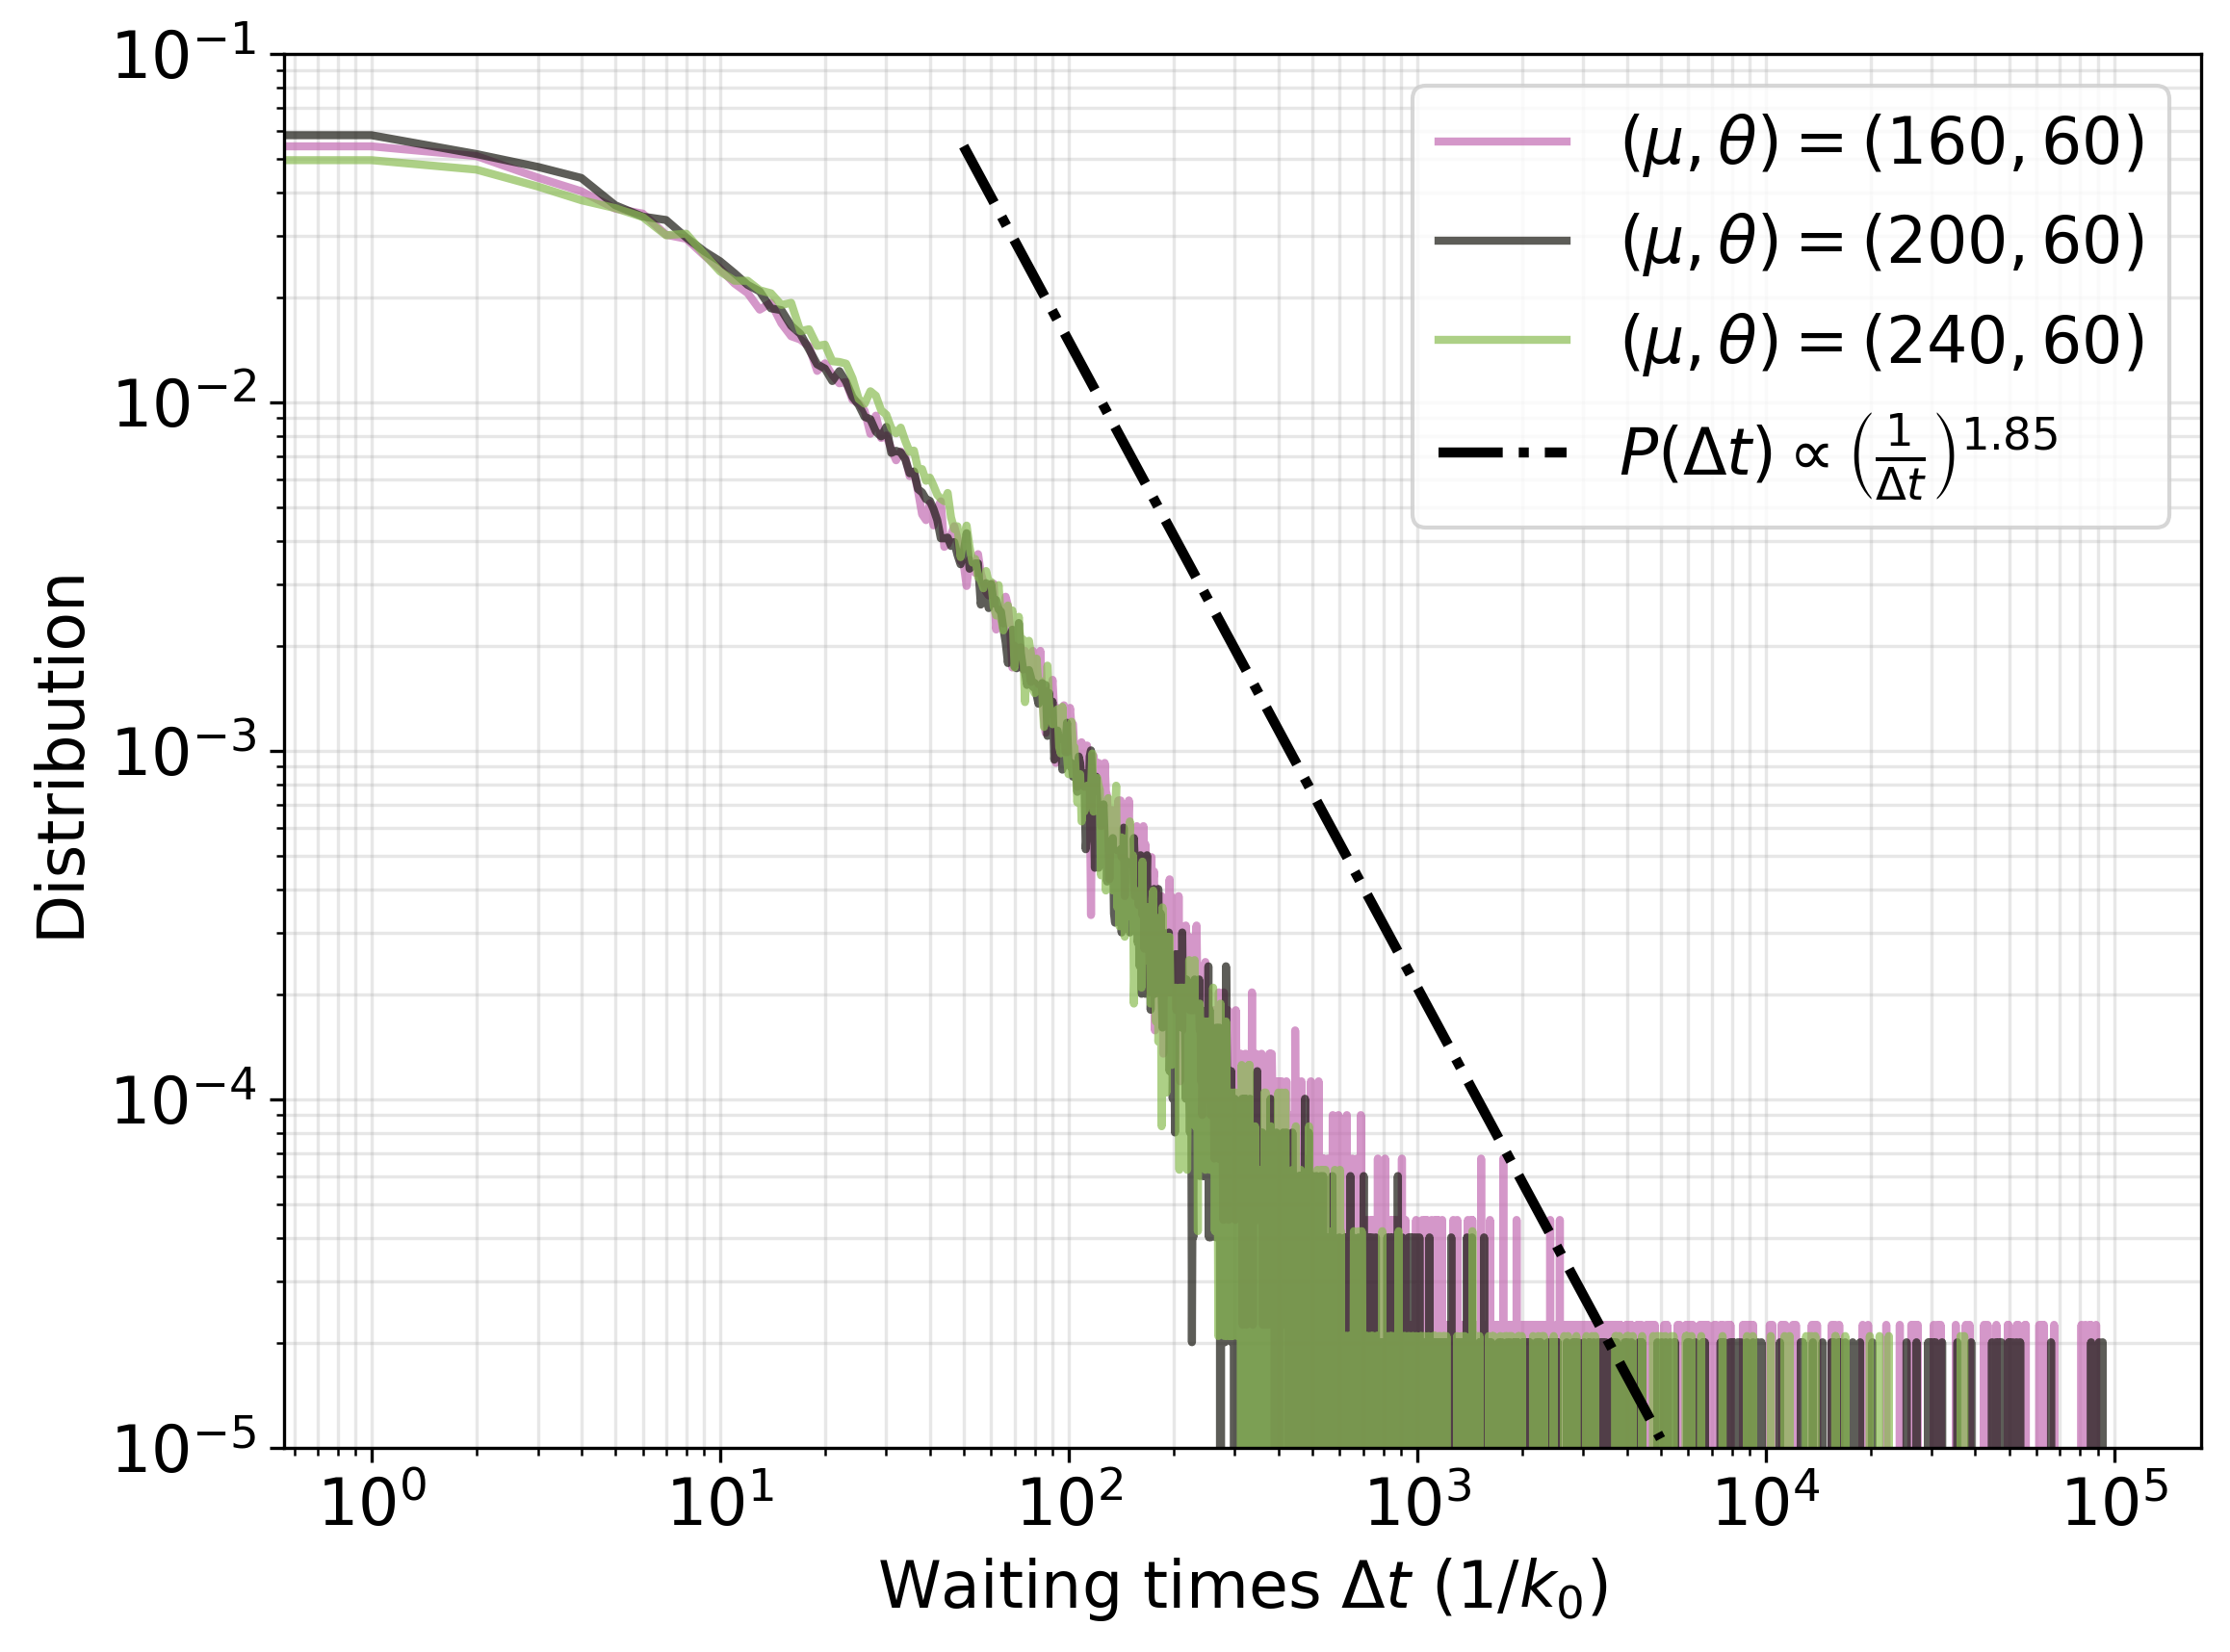

In [69]:
# ── Imports ──────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from nucleo.io.reading import finding_one_parquet


# ── Paramètres ────────────────────────────────────────────────────────────────

mus = [160, 200, 240]
theta = 60

params_shared = {
    'algo': "1S",
    'dstr': False,
    'fact': False,
    'mode': "none",

    "s": 150,
    "l": 10,
    "bpmin": 0,
    "theta": theta,

    'Kz': 0.00,
    'Kp': 0.00,
    'alphar': 0.00,
}

# Décalage PUREMENT VISUEL de la courbe de fit vers la droite, pour la
# dissocier des données à l'affichage. Les valeurs y du fit ne changent
# pas : on garde les y calculés sur la vraie zone de fit, on translate
# juste leur position en x sur le graphe.
DISPLAY_SHIFT_LIN = 0     # pour homogen / periodic (décalage additif en x)
DISPLAY_SHIFT_FACTOR = 5  # pour random (échelle log -> décalage multiplicatif)


# ── Couleurs ──────────────────────────────────────────────────────────────────

cmap = cm.get_cmap("vanimo")

color_positions = np.linspace(
    0.15,
    0.90,
    len(mus)
)

color_list = [
    cmap(pos)
    for pos in color_positions
]


# ── Figures ───────────────────────────────────────────────────────────────────

for land in ["homogen", "periodic", "random"]:

    fig, ax = plt.subplots(
        figsize=(8, 6),
        dpi=300
    )

    params = params_shared.copy()
    params["land"] = land

    # ========================================================================
    # Chargement des données (une seule fois par mu, réutilisé ensuite)
    # ========================================================================

    data = {}

    for idx, mu in enumerate(mus):

        params["mu"] = mu

        df = finding_one_parquet(
            root,
            params
        )

        x = df["tbj_points"][0].to_numpy()
        y = df["tbj_distrib"][0].to_numpy()

        data[mu] = (x, y)

        color = color_list[idx]

        ax.plot(
            x,
            y,
            color=color,
            ls="-",
            lw=2,
            alpha=0.70,
            label=fr"$(\mu,\theta)=({mu},{theta})$"
        )

    # ========================================================================
    # HOMOGENEOUS / PERIODIC
    # Fit exponentiel GLOBAL (les 3 mu poolés ensemble) sur [5, 50]
    # ========================================================================

    if land in ["homogen", "periodic"]:

        fit_lo, fit_hi = 10, 1000

        # ── Pool des points des 3 courbes dans la zone de fit ──────────────

        x_pool = []
        y_pool = []

        for mu in mus:

            x, y = data[mu]

            mask = (
                np.isfinite(x)
                & np.isfinite(y)
                & (x >= fit_lo)
                & (x <= fit_hi)
                & (y > 0)
            )

            x_pool.append(x[mask])
            y_pool.append(y[mask])

        x_pool = np.concatenate(x_pool)
        y_pool = np.concatenate(y_pool)

        # ── Fit unique sur l'ensemble des points poolés ─────────────────────
        # ln(P) = slope * dt + intercept

        slope, intercept = np.polyfit(
            x_pool,
            np.log(y_pool),
            1
        )

        lambda_fit = -slope

        # ── Droite issue directement du fit, sur sa vraie zone ──────────────

        x_ref = np.linspace(
            fit_lo,
            fit_hi,
            300
        )

        y_ref = np.exp(
            intercept + slope * x_ref
        )

        # ── Décalage purement visuel (x seulement) pour dissocier de la
        #    donnée à l'affichage — les y_ref ne sont PAS recalculés ────────

        x_display = x_ref + DISPLAY_SHIFT_LIN

        ax.plot(
            x_display,
            y_ref,
            color="black",
            ls="-.",
            lw=2.5,
            label=(
                fr"$P(\Delta t)\propto e^{{-\lambda\Delta t}}$, "
                fr"$\lambda={lambda_fit:.3f}$"
            )
        )

        ax.set_ylim([-0.005, 0.07])

    # ========================================================================
    # RANDOM
    # Fit loi d'échelle GLOBAL (les 3 mu poolés ensemble) sur [10, 1000]
    # ========================================================================

    else:

        fit_lo, fit_hi = 10, 1000

        # ── Pool des points des 3 courbes dans la zone de fit ──────────────

        x_pool = []
        y_pool = []

        for mu in mus:

            x, y = data[mu]

            mask = (
                np.isfinite(x)
                & np.isfinite(y)
                & (x >= fit_lo)
                & (x <= fit_hi)
                & (y > 0)
            )

            x_pool.append(x[mask])
            y_pool.append(y[mask])

        x_pool = np.concatenate(x_pool)
        y_pool = np.concatenate(y_pool)

        # ── Fit unique sur l'ensemble des points poolés ─────────────────────
        # ln(P) = slope * ln(dt) + intercept

        slope, intercept = np.polyfit(
            np.log(x_pool),
            np.log(y_pool),
            1
        )

        alpha_fit = -slope

        # ── Courbe issue directement du fit, sur sa vraie zone ──────────────

        x_ref = np.logspace(
            np.log10(fit_lo),
            np.log10(fit_hi),
            300
        )

        y_ref = np.exp(
            intercept + slope * np.log(x_ref)
        )

        # ── Décalage purement visuel (x seulement) pour dissocier de la
        #    donnée à l'affichage — en échelle log, un décalage "propre"
        #    est multiplicatif — les y_ref ne sont PAS recalculés ──────────

        x_display = x_ref * DISPLAY_SHIFT_FACTOR

        ax.plot(
            x_display,
            y_ref,
            color="black",
            ls="-.",
            lw=2.5,
            label=(
                r"$P(\Delta t)\propto"
                r"\left(\frac{1}{\Delta t}\right)^{"
                f"{alpha_fit:.2f}"
                r"}$"
            )
        )

    # ========================================================================
    # Mise en forme
    # ========================================================================

    # ax.set_title(
    #     land.capitalize()
    # )

    ax.set_xlabel(
        r"Waiting times $\Delta t\ (1/k_0)$"
    )

    ax.set_ylabel(
        "Distribution"
    )

    # ── Échelles ─────────────────────────────────────────────────────────────

    if land in ["homogen", "periodic"]:

        print(land)

        # Log-lin
        ax.set_yscale("log")
        ax.set_xlim([0, 200])
        ax.set_ylim([1e-5, 1e-1])

    else:

        # Log-log
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylim([1e-5, 1e-1])

    # ── Grille ───────────────────────────────────────────────────────────────

    ax.grid(
        True,
        alpha=0.3,
        which="both"
    )

    # ── Légende ──────────────────────────────────────────────────────────────

    ax.legend(
        loc="upper right",
        frameon=True
    )

    # ── Sauvegarde ──────────────────────────────────────────────────────────

    fig.tight_layout()

    plt.savefig(
        f"supfig3_{land}_meanfit.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# .